# Latin BERT on LatinISE for Christian-related semantic change

The structure of this notebook is as follows:
- Import packages and define functions
- Set up metadata dataframes
    - Redefine the timeframe of interest (LatinISE covers a wide timespan, but we are only interested in Latin while a living language)
    - Define time slices (so that the first precedes Christian Latin texts and the second one contains them)
    - Define Christian and non-Christian subcorpora within second timeframe
- Build corpus and subcorpora
- Pre-trained Latin BERT
    - Load embeddings and lemmatize keys for analysis
    - Average embeddings per word type and calculate cosine similarity across subcorpora
    - Try different techniques for clustering embeddings as to maintain sense distinction
    - Plot some results via PCA and t-SNE
- Fine-tuned Latin BERT
    - Repeat loading, averaging, clustering, and plotting

WARNING: it might not be possible to work on both the pre-trained and the finetuned models in the same run (the kernel might die if you try to load embeddings for both).

## Packages and functions

### Packages

Import packages:

In [2]:
import os 
import csv
import pickle
import h5py
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import silhouette_score
from sklearn.cluster import AffinityPropagation
from sklearn.manifold import trustworthiness

### Rebuild

Set `rebuild` to either `True` or `False` as needed. If this is your first time running this code, set `rebuild` to `True`, otherwise set `rebuild` to `False` to load the files produced on the first run (this will save you some time):

In [3]:
rebuild = True

### Functions

Define frequently used or nested functions:

(1) `load_embeddings_h5` loads embeddings from the previously produced hdf5 file; these come in the form of a list of sentences, each sentence containing token-embedding pairs.

(3) `average_embeddings_by_lemma` computes an average embedding for each lemma (using the lemmatized form attached to each token embedding) and saves them to an hdf5 file (if `rebuild = True`) or loads them from the previously saved file (if `rebuild = False`); also prints the averaged embeddings for the 10 most frequent words as sample. 

(4) `find_neighbors` shows which averaged embeddings are most similar to the target embedding, and displays the cosine similarity score for each of them.

(5) `plot_neighbors` plots the target embedding and its neighbors in a reduced-dimentional space.

(6) `save_neighbors` saves neighbors for a pre-defined list of words to a csv file.

(7) `compute_apd` and `compute_apd_selected` compute average pairwise distance (see futher down in notebook for details) for a pre-defined set of embeddings.

(8) `cluster_target_embeddings` does the same, but does not rely on `rebuild` or previously defined files.

(8) MIGHT NEED TO SUB WITH `extract_sense_prototypes`

(9) `extract_selected_embeddings` extracts embeddings only for a given set of words for more targeted and easier processing.

(10) `plot_token_embeddings_with_highlight` colour-codes embeddings from Christian set of texts vs. non-Christian set of texts within t1.

(11) `plot_token_embeddings_with_highlight_tsne` – FINISH

(12) `optimal_num_clusters` – FINISH

In [4]:
def load_embeddings_h5(output_filename, dir_out, batch_size=1000):
    output_path = os.path.join(dir_out, output_filename)
    if not os.path.exists(output_path):
        print(f"Embeddings file {output_path} not found.")
        return None

    def decode_value(value):
        if isinstance(value, bytes):
            return value.decode("utf-8")
        return value

    sentence_fields = {
        "source_text_index",
        "sentence_index",
        "sentence_text",
        "sentence_char_start",
        "sentence_char_end",
        "n_matched_words",
    }

    print(f"Loading embeddings from {output_path} in batches...")
    records = []

    with h5py.File(output_path, "r") as f:
        sent_keys = list(f.keys())

        for batch_start in range(0, len(sent_keys), batch_size):
            batch_keys = sent_keys[batch_start:batch_start + batch_size]

            for sent_key in batch_keys:
                grp = f[sent_key]

                sentence_metadata = {}
                csv_metadata = {}

                for key, value in grp.attrs.items():
                    if key.startswith("word_"):
                        continue

                    decoded = decode_value(value)

                    if key in sentence_fields:
                        sentence_metadata[key] = decoded
                    else:
                        csv_metadata[key] = decoded

                token_specs = sorted(
                    [
                        (int(parts[1]), key)
                        for key in grp.keys()
                        if key.endswith("_embedding")
                        for parts in [key.split("_")]
                        if len(parts) >= 3 and parts[1].isdigit()
                    ],
                    key=lambda item: item[0],
                )

                tokens = []
                for idx, emb_key in token_specs:
                    surface = decode_value(grp.attrs.get(f"word_{idx:04d}_surface"))
                    lemma = decode_value(grp.attrs.get(f"word_{idx:04d}_normalized", surface))

                    tokens.append(
                        {
                            "surface": surface,
                            "lemma": lemma,
                            "embedding": grp[emb_key][()],
                            "char_start": grp.attrs.get(f"word_{idx:04d}_char_start"),
                            "char_end": grp.attrs.get(f"word_{idx:04d}_char_end"),
                            "chunk_index": grp.attrs.get(f"word_{idx:04d}_chunk_index"),
                            "sentence_relative_start": grp.attrs.get(f"word_{idx:04d}_sentence_relative_start"),
                            "sentence_relative_end": grp.attrs.get(f"word_{idx:04d}_sentence_relative_end"),
                        }
                    )

                records.append(
                    {
                        "sentence_key": sent_key,
                        "sentence_metadata": sentence_metadata,
                        "csv_metadata": csv_metadata,
                        "tokens": tokens,
                    }
                )

    return records

In [93]:
def average_embeddings_by_lemma(
    records,
    dir_out,
    output_filename,
    rebuild,
    num_most_frequent=10,
    metadata_fields=None,
    max_examples=5,
    return_metadata=False,
):
    """
    Average token embeddings per lemma and store/load them from HDF5.

    Parameters:
    - records: output of load_embeddings_h5(...)
    - dir_out: output directory
    - output_filename: HDF5 file name
    - rebuild: if True, recompute and overwrite; if False, load from file
    - num_most_frequent: number of lemmas to print
    - metadata_fields: CSV metadata fields to aggregate, e.g. ["time_slice", "file"]
    - max_examples: number of example sentences to retain per lemma
    - return_metadata: if True, also return metadata summaries

    Returns:
    - average_embeddings: dict {lemma: embedding_vector}
    - most_frequent_words: list of lemmas
    - lemma_metadata (optional): dict with counts / surface forms / metadata summaries
    """
    os.makedirs(dir_out, exist_ok=True)
    output_path = os.path.join(dir_out, output_filename)
    if not output_path.endswith(".h5"):
        output_path += ".h5"

    if metadata_fields is None:
        metadata_fields = ["time_slice", "file"]

    string_dtype = h5py.string_dtype(encoding="utf-8")

    def save_counter_group(parent_group, group_name, counter_obj):
        group = parent_group.create_group(group_name)
        labels = list(counter_obj.keys())
        counts = [counter_obj[label] for label in labels]
        group.create_dataset("labels", data=np.array(labels, dtype=string_dtype))
        group.create_dataset("counts", data=np.array(counts, dtype=np.int64))

    def load_counter_group(group):
        labels = [label.decode("utf-8") if isinstance(label, bytes) else label for label in group["labels"][()]]
        counts = group["counts"][()].tolist()
        return dict(zip(labels, counts))

    def load_average_embeddings_h5(h5_path):
        average_embeddings = {}
        lemma_metadata = {}

        with h5py.File(h5_path, "r") as h5f:
            lemma_keys = list(h5f.keys())

            for lemma_key in lemma_keys:
                grp = h5f[lemma_key]
                lemma = grp.attrs["lemma"]
                if isinstance(lemma, bytes):
                    lemma = lemma.decode("utf-8")

                average_embeddings[lemma] = grp["embedding"][()]
                lemma_metadata[lemma] = {
                    "count": int(grp.attrs["count"]),
                    "surface_forms": load_counter_group(grp["surface_forms"]) if "surface_forms" in grp else {},
                    "metadata": {},
                    "examples": [],
                }

                if "metadata" in grp:
                    for field_name in grp["metadata"].keys():
                        lemma_metadata[lemma]["metadata"][field_name] = load_counter_group(grp["metadata"][field_name])

                if "examples" in grp:
                    examples_grp = grp["examples"]
                    example_count = len(examples_grp["sentence_keys"])
                    for index in range(example_count):
                        sentence_key = examples_grp["sentence_keys"][index]
                        sentence_text = examples_grp["sentence_texts"][index]
                        surface = examples_grp["surfaces"][index]
                        file_value = examples_grp["files"][index]
                        time_slice = examples_grp["time_slices"][index]

                        lemma_metadata[lemma]["examples"].append(
                            {
                                "sentence_key": sentence_key.decode("utf-8") if isinstance(sentence_key, bytes) else sentence_key,
                                "sentence_text": sentence_text.decode("utf-8") if isinstance(sentence_text, bytes) else sentence_text,
                                "surface": surface.decode("utf-8") if isinstance(surface, bytes) else surface,
                                "file": file_value.decode("utf-8") if isinstance(file_value, bytes) else file_value,
                                "time_slice": time_slice.decode("utf-8") if isinstance(time_slice, bytes) else time_slice,
                            }
                        )

        return average_embeddings, lemma_metadata

    if rebuild:
        lemma_sums = {}
        lemma_counts = Counter()
        surface_forms = defaultdict(Counter)
        metadata_counters = defaultdict(lambda: defaultdict(Counter))
        examples = defaultdict(list)

        for record in records:
            sentence_key = record["sentence_key"]
            sentence_text = record["sentence_metadata"].get("sentence_text", "")
            csv_metadata = record.get("csv_metadata", {})

            for token in record["tokens"]:
                lemma = token["lemma"]
                embedding = np.asarray(token["embedding"], dtype=np.float64)

                if lemma not in lemma_sums:
                    lemma_sums[lemma] = embedding.copy()
                else:
                    lemma_sums[lemma] += embedding

                lemma_counts[lemma] += 1
                surface_forms[lemma][token["surface"]] += 1

                for field in metadata_fields:
                    if field in csv_metadata:
                        metadata_counters[lemma][field][str(csv_metadata[field])] += 1

                if len(examples[lemma]) < max_examples:
                    examples[lemma].append(
                        {
                            "sentence_key": sentence_key,
                            "sentence_text": sentence_text,
                            "surface": token["surface"],
                            "file": str(csv_metadata.get("file", "")),
                            "time_slice": str(csv_metadata.get("time_slice", "")),
                        }
                    )

        average_embeddings = {}
        lemma_metadata = {}

        for lemma, total_vector in lemma_sums.items():
            mean_vector = total_vector / lemma_counts[lemma]
            average_embeddings[lemma] = normalize(mean_vector.reshape(1, -1))[0]

            lemma_metadata[lemma] = {
                "count": int(lemma_counts[lemma]),
                "surface_forms": dict(surface_forms[lemma]),
                "metadata": {
                    field: dict(counter_obj)
                    for field, counter_obj in metadata_counters[lemma].items()
                },
                "examples": examples[lemma],
            }

        with h5py.File(output_path, "w") as h5f:
            h5f.attrs["format"] = "lemma_average_embeddings"
            h5f.attrs["metadata_fields"] = np.array(metadata_fields, dtype=string_dtype)

            for index, lemma in enumerate(sorted(average_embeddings.keys())):
                grp = h5f.create_group(f"lemma_{index:05d}")
                grp.attrs["lemma"] = lemma
                grp.attrs["count"] = lemma_metadata[lemma]["count"]

                grp.create_dataset("embedding", data=average_embeddings[lemma], compression="gzip")

                save_counter_group(grp, "surface_forms", lemma_metadata[lemma]["surface_forms"])

                metadata_grp = grp.create_group("metadata")
                for field, counter_obj in lemma_metadata[lemma]["metadata"].items():
                    save_counter_group(metadata_grp, field, counter_obj)

                examples_grp = grp.create_group("examples")
                examples_grp.create_dataset(
                    "sentence_keys",
                    data=np.array([example["sentence_key"] for example in lemma_metadata[lemma]["examples"]], dtype=string_dtype),
                )
                examples_grp.create_dataset(
                    "sentence_texts",
                    data=np.array([example["sentence_text"] for example in lemma_metadata[lemma]["examples"]], dtype=string_dtype),
                )
                examples_grp.create_dataset(
                    "surfaces",
                    data=np.array([example["surface"] for example in lemma_metadata[lemma]["examples"]], dtype=string_dtype),
                )
                examples_grp.create_dataset(
                    "files",
                    data=np.array([example["file"] for example in lemma_metadata[lemma]["examples"]], dtype=string_dtype),
                )
                examples_grp.create_dataset(
                    "time_slices",
                    data=np.array([example["time_slice"] for example in lemma_metadata[lemma]["examples"]], dtype=string_dtype),
                )

        print(f"Average embeddings saved to {output_path}")

    else:
        average_embeddings, lemma_metadata = load_average_embeddings_h5(output_path)

    most_frequent_words = sorted(
        lemma_metadata.keys(),
        key=lambda lemma: lemma_metadata[lemma]["count"],
        reverse=True,
    )[:num_most_frequent]

    for word in most_frequent_words:
        print(f"Word: {word}")
        print(f"Count: {lemma_metadata[word]['count']}")
        print(f"Top surface forms: {Counter(lemma_metadata[word]['surface_forms']).most_common(5)}")
        print(f"Embedding: {average_embeddings[word]}\n")

    if return_metadata:
        return average_embeddings, most_frequent_words, lemma_metadata

    return average_embeddings, most_frequent_words

In [6]:
def find_neighbors(target_word, average_embeddings, top_k=5):
    """
    Find the top-k nearest neighbors for the target word using precomputed average embeddings.

    Parameters:
    - target_word: The word for which to find neighbors.
    - average_embeddings: Dictionary of precomputed average embeddings for each word.
    - top_k: Number of nearest neighbors to find.

    Returns:
    - neighbors: List of nearest neighbors for the target word.
    """
    if target_word not in average_embeddings:
        raise ValueError(f"Word '{target_word}' not found in the corpus.")

    target_embedding = average_embeddings[target_word].reshape(1, -1)
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[word] for word in all_words])

    # Compute cosine similarities
    similarities = cosine_similarity(target_embedding, all_embeddings).squeeze()

    # Exclude target word and find the top-k neighbors
    neighbors = sorted(
        [(word, sim) for word, sim in zip(all_words, similarities) if word != target_word],
        key=lambda x: -x[1]
    )[:top_k]

    return neighbors

In [ ]:
def plot_neighbors(target_word, neighbors, average_embeddings, n_components=2, output_dir=None, time_slice=None):
    """
    Plot the target word and its neighbors in a reduced-dimensional space.

    Parameters:
    - target_word: The word for which neighbors were found.
    - neighbors: List of tuples (neighbor_word, similarity) from find_neighbors.
    - average_embeddings: Dictionary of precomputed average embeddings for each word.
    - n_components: Number of dimensions to reduce to (default is 2).
    - output_dir: Directory to save the plot. If None, plot is not saved.
    - time_slice: Optional string or identifier for the time slice to include in the filename.
    """
    # Collect embeddings for the target word and its neighbors
    words = [target_word] + [neighbor[0] for neighbor in neighbors]
    embeddings = [average_embeddings[word] for word in words]

    # Reduce dimensionality using PCA
    pca = PCA(n_components=n_components)
    reduced_embeddings = pca.fit_transform(embeddings)

    # Plot the embeddings
    plt.figure(figsize=(8, 6))
    for i, word in enumerate(words):
        x, y = reduced_embeddings[i]
        plt.scatter(x, y, label=word, s=100 if word == target_word else 50, alpha=0.8)
        plt.text(x + 0.02, y + 0.02, word, fontsize=10)

    plt.title(f"Neighbors of '{target_word}' in Reduced Space")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    #plt.legend()
    plt.grid(True)

    # Save the plot if output_dir is provided
    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        if time_slice is not None:
            filename = f"neighbors_{target_word}_{time_slice}.png"
        else:
            filename = f"neighbors_{target_word}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {filepath}")

    plt.show()

In [8]:
def save_neighbors(word_list, average_embeddings, top_k, output_dir, output_filename="neighbors.csv"):
    """
    For each word in word_list, find its top_k neighbors and save results to a CSV in the specified directory.
    """
    os.makedirs(output_dir, exist_ok=True)
    output_csv = os.path.join(output_dir, output_filename)
    with open(output_csv, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Target Word", "Neighbor", "Cosine Similarity"])
        for word in word_list:
            try:
                neighbors = find_neighbors(word, average_embeddings, top_k=top_k)
                for neighbor, sim in neighbors:
                    writer.writerow([word, neighbor, sim])
            except Exception as e:
                print(f"Skipping '{word}': {e}")
    print(f"Neighbors saved to {output_csv}")

In [9]:
def compute_apd(embeddings1, embeddings2):
    if len(embeddings1) == 0 or len(embeddings2) == 0:
        return None
    A = np.stack(embeddings1)
    B = np.stack(embeddings2)
    similarities = cosine_similarity(A, B)
    distances = 1 - similarities  # cosine distance
    return np.mean(distances)

def compute_apd_selected(embeddings_t0, embeddings_t1):
    apd_scores = {}
    shared_lemmas = set(embeddings_t0.keys()) & set(embeddings_t1.keys())

    for lemma in shared_lemmas:
        emb_t0 = embeddings_t0[lemma]
        emb_t1 = embeddings_t1[lemma]
        
        if len(emb_t0) == 0 or len(emb_t1) == 0:
            print(f"Skipping {lemma}: empty embeddings")
            continue

        apd = compute_apd(emb_t0, emb_t1)
        if apd is not None:
            apd_scores[lemma] = apd

    return apd_scores

In [10]:
def cluster_target_embeddings(word_embeddings, num_clusters=3):
    clustered_embeddings = {}
    for word, embeddings in word_embeddings.items():
        if len(embeddings) < num_clusters:
            # If there are fewer embeddings than clusters, use the embeddings as they are
            clustered_embeddings[word] = embeddings
        else:
            # Convert list of embeddings to a numpy array
            embeddings_array = np.array(embeddings)
            # Apply K-Means clustering
            kmeans = KMeans(n_clusters=num_clusters, random_state=0)
            kmeans.fit(embeddings_array)
            # Use cluster centroids as sense embeddings
            clustered_embeddings[word] = kmeans.cluster_centers_
    return clustered_embeddings

In [11]:
def extract_sense_prototypes(word_embeddings, clustering_cls=KMeans, num_clusters=3, **clustering_kwargs):
    """
    For each word, cluster its embeddings and return the cluster centroids as sense prototypes.
    clustering_cls: clustering class (e.g., KMeans, AffinityPropagation, etc.)
    num_clusters: number of clusters (if applicable)
    clustering_kwargs: additional arguments for the clustering class
    """
    sense_prototypes = {}
    for word, embeddings in word_embeddings.items():
        if len(embeddings) < num_clusters:
            sense_prototypes[word] = embeddings
        else:
            embeddings_array = np.array(embeddings)
            if clustering_cls == KMeans:
                clusterer = clustering_cls(n_clusters=num_clusters, random_state=0, **clustering_kwargs)
            else:
                clusterer = clustering_cls(**clustering_kwargs)
            clusterer.fit(embeddings_array)
            if hasattr(clusterer, "cluster_centers_"):
                sense_prototypes[word] = clusterer.cluster_centers_
            else:
                # For clustering algorithms without centroids, use exemplars or medoids if available
                sense_prototypes[word] = embeddings_array[clusterer.cluster_centers_indices_]
    return sense_prototypes

In [44]:
def extract_selected_embeddings(bert_sents, selected_words, match_on="lemma"):
    """
    Extract embeddings for selected words from embeddings data.

    Parameters:
    - bert_sents: Either
      (a) list of records from `load_embeddings_h5` with `record["tokens"]`, or
      (b) legacy list of sentences with tuples: [(lemma, embedding), ...]
    - selected_words: List of words for which to extract embeddings
    - match_on: "lemma" (default) or "surface" when using record format

    Returns:
    - selected_word_embeddings: Dictionary of embeddings for each selected word
    """
    if match_on not in {"lemma", "surface"}:
        raise ValueError("match_on must be either 'lemma' or 'surface'")

    selected_set = set(selected_words)
    selected_word_embeddings = defaultdict(list)

    for sent in bert_sents:
        if isinstance(sent, dict) and "tokens" in sent:
            for token in sent["tokens"]:
                key = token["lemma"] if match_on == "lemma" else token["surface"]
                if key in selected_set:
                    selected_word_embeddings[key].append(token["embedding"])
        else:
            for lemma, embedding in sent:
                if lemma in selected_set:
                    selected_word_embeddings[lemma].append(embedding)

    return selected_word_embeddings

In [71]:
def plot_token_embeddings_with_highlight_pca(
    records_t1,
    target_token,
    n_components=2,
    match_on="lemma",          # "lemma" or "surface"
    ridge_label="youden",      # "youden" or "f1"
    positive_label="christian",          # value to highlight as red
    save=True,
    max_points=5000, 
    random_state=42
):
    """
    Plot embeddings for a target token and color points by ridge metadata label.

    Colors:
    - red: record `label_ridge_<ridge_label>` matches `positive_label` (e.g., "christian")
    - blue: all other labeled instances (e.g., "non-christian")
    """
    if match_on not in {"lemma", "surface"}:
        raise ValueError("match_on must be 'lemma' or 'surface'")
    if ridge_label not in {"youden", "f1"}:
        raise ValueError("ridge_label must be 'youden' or 'f1'")

    label_key = f"label_ridge_{ridge_label}"  # "youden" or "f1"
    positive_label = str(positive_label).strip().lower()  # e.g. "christian"
    target_token = str(target_token).strip().lower()

    embeddings = []
    colors = []
    labels_used = []

    for record in records_t1:
        label_value = str(record.get("csv_metadata", {}).get(label_key, "")).strip().lower()
        if not label_value:
            continue

        for token in record.get("tokens", []):
            token_value = str(token.get(match_on, "")).strip().lower()
            if token_value == target_token:
                embeddings.append(np.asarray(token["embedding"]))
                labels_used.append(label_value)
                colors.append("red" if label_value == positive_label else "blue")

    if not embeddings:
        print(
            f"No instances of '{target_token}' found "
            f"(match_on='{match_on}', label key='{label_key}')."
        )
        return

    embeddings_np = np.stack(embeddings)

    # Optional cap for visualization speed/readability
    if max_points is not None and len(embeddings_np) > max_points:
        rng = np.random.default_rng(random_state)

        idx_pos = np.array([i for i, c in enumerate(colors) if c == "red"])
        idx_neg = np.array([i for i, c in enumerate(colors) if c == "blue"])

        n_pos = int(round(max_points * len(idx_pos) / len(embeddings_np)))
        n_neg = max_points - n_pos

        keep_pos = rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False) if len(idx_pos) else np.array([], dtype=int)
        keep_neg = rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False) if len(idx_neg) else np.array([], dtype=int)

        keep_idx = np.concatenate([keep_pos, keep_neg])
        rng.shuffle(keep_idx)

        embeddings_np = embeddings_np[keep_idx]
        colors = [colors[i] for i in keep_idx]

    # keep PCA safe for small sample sizes
    max_valid_components = min(embeddings_np.shape[0], embeddings_np.shape[1])
    pca_components = min(n_components, max_valid_components)
    pca = PCA(n_components=pca_components)
    reduced = pca.fit_transform(embeddings_np)

    x = reduced[:, 0]
    y = reduced[:, 1] if reduced.shape[1] > 1 else np.zeros_like(x)

    plt.figure(figsize=(10, 7))
    plt.scatter(x, y, c=colors, s=14, alpha=0.28, edgecolors="none")

    neg_label = next((lab for lab in set(labels_used) if lab != positive_label), "other")

    from matplotlib.lines import Line2D
    legend_items = [
        Line2D([0], [0], marker='o', color='w',
               label=f"{label_key}={positive_label}",
               markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='o', color='w',
               label=f"{label_key}={neg_label}",
               markerfacecolor='blue', markersize=8),
    ]
    plt.legend(handles=legend_items, title="Highlight source")

    plt.title(f"PCA of '{target_token}' embeddings in t1")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)

    if save:
        output_path = os.path.join(dir_in, "output", "PCA")
        os.makedirs(output_path, exist_ok=True)
        plot_filename = os.path.join(
            output_path,
            f"pca_embeddings_{target_token}_t1_ridge-{ridge_label}.png"
        )
        plt.savefig(plot_filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved to {plot_filename}")

    plt.show()

In [70]:
def plot_token_embeddings_with_highlight_tsne(
    records_t1,
    target_token,
    match_on="lemma",              # "lemma" or "surface"
    ridge_label="youden",          # "youden" or "f1"
    positive_label="christian",    # value to highlight as red
    save=True,
    max_points=2000,               # lower default for t-SNE
    random_state=42,
    tsne_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    pca_pre_reduce=50              # set None to disable pre-PCA
):
    """
    Plot embeddings for a target token with t-SNE and color by ridge metadata label.

    Colors:
    - red: record `label_ridge_<ridge_label>` matches `positive_label` (e.g., "christian")
    - blue: all other labeled instances (e.g., "non-christian")
    """
    if match_on not in {"lemma", "surface"}:
        raise ValueError("match_on must be 'lemma' or 'surface'")
    if ridge_label not in {"youden", "f1"}:
        raise ValueError("ridge_label must be 'youden' or 'f1'")
    if tsne_components < 2:
        raise ValueError("tsne_components should be >= 2 for plotting")

    label_key = f"label_ridge_{ridge_label}"
    positive_label = str(positive_label).strip().lower()
    target_token = str(target_token).strip().lower()

    embeddings = []
    colors = []
    labels_used = []

    for record in records_t1:
        label_value = str(record.get("csv_metadata", {}).get(label_key, "")).strip().lower()
        if not label_value:
            continue

        for token in record.get("tokens", []):
            token_value = str(token.get(match_on, "")).strip().lower()
            if token_value == target_token:
                embeddings.append(np.asarray(token["embedding"]))
                labels_used.append(label_value)
                colors.append("red" if label_value == positive_label else "blue")

    if not embeddings:
        print(
            f"No instances of '{target_token}' found "
            f"(match_on='{match_on}', label key='{label_key}')."
        )
        return

    embeddings_np = np.stack(embeddings)

    # Optional cap for visualization speed/readability (stratified by class color)
    if max_points is not None and len(embeddings_np) > max_points:
        rng = np.random.default_rng(random_state)

        idx_pos = np.array([i for i, c in enumerate(colors) if c == "red"])
        idx_neg = np.array([i for i, c in enumerate(colors) if c == "blue"])

        n_pos = int(round(max_points * len(idx_pos) / len(embeddings_np)))
        n_neg = max_points - n_pos

        keep_pos = rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False) if len(idx_pos) else np.array([], dtype=int)
        keep_neg = rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False) if len(idx_neg) else np.array([], dtype=int)

        keep_idx = np.concatenate([keep_pos, keep_neg])
        rng.shuffle(keep_idx)

        embeddings_np = embeddings_np[keep_idx]
        colors = [colors[i] for i in keep_idx]
        labels_used = [labels_used[i] for i in keep_idx]

    n_samples = embeddings_np.shape[0]
    if n_samples < 3:
        print(f"Not enough points for t-SNE ({n_samples} found).")
        return

    # t-SNE requires perplexity < n_samples
    safe_perplexity = min(perplexity, max(2, n_samples - 1))

    # Optional PCA pre-reduction (often helps t-SNE stability/speed)
    if pca_pre_reduce is not None and embeddings_np.shape[1] > pca_pre_reduce:
        pca_dim = min(pca_pre_reduce, embeddings_np.shape[0], embeddings_np.shape[1])
        embeddings_for_tsne = PCA(n_components=pca_dim).fit_transform(embeddings_np)
    else:
        embeddings_for_tsne = embeddings_np

    tsne = TSNE(
        n_components=tsne_components,
        perplexity=safe_perplexity,
        random_state=random_state,
        learning_rate=learning_rate,
        init=init
    )
    reduced = tsne.fit_transform(embeddings_for_tsne)

    x = reduced[:, 0]
    y = reduced[:, 1]

    plt.figure(figsize=(10, 7))
    plt.scatter(x, y, c=colors, s=14, alpha=0.28, edgecolors="none")

    neg_label = next((lab for lab in set(labels_used) if lab != positive_label), "other")

    from matplotlib.lines import Line2D
    legend_items = [
        Line2D([0], [0], marker='o', color='w',
               label=f"{label_key}={positive_label}",
               markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='o', color='w',
               label=f"{label_key}={neg_label}",
               markerfacecolor='blue', markersize=8),
    ]
    plt.legend(handles=legend_items, title="Highlight source")

    plt.title(f"t-SNE of '{target_token}' embeddings in t1")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True)

    if save:
        output_path = os.path.join(dir_in, "output", "TSNE")
        os.makedirs(output_path, exist_ok=True)
        plot_filename = os.path.join(
            output_path,
            f"tsne_embeddings_{target_token}_t1_ridge-{ridge_label}.png"
        )
        plt.savefig(plot_filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved to {plot_filename}")

    plt.show()

In [ ]:
def visualize_embeddings_pca_tsne(
    embeddings,
    pca_components=100,
    tsne_perplexity=30,
    title="t-SNE Visualization",
    save_path=None,
    word=None,
    timepoint=None,
    finetuned=False
):
    """
    Reduces dimensionality of embeddings using PCA and t-SNE, then plots and optionally saves the result.

    Parameters:
        embeddings (ndarray): High-dimensional input data (e.g. word embeddings).
        pca_components (int): Number of PCA components before applying t-SNE.
        tsne_perplexity (float): Perplexity parameter for t-SNE.
        title (str): Title for the plot.
        save_path (str or None): Directory where the plot will be saved. If None, plot is not saved.
        word (str or None): Used in filename if save_path is provided.
        timepoint (str or None): Used in filename if save_path is provided.
        finetuned (bool): Adds '_finetuned' to filename if True.
    """
    embeddings = np.asarray(embeddings)
    if embeddings.ndim != 2:
        raise ValueError(f"embeddings must be 2D, got shape {embeddings.shape}")

    n_samples, n_features = embeddings.shape
    if n_samples < 3:
        raise ValueError(f"Need at least 3 samples for t-SNE, got {n_samples}")

    pca_dim = max(1, min(int(pca_components), n_samples, n_features))

    # PCA
    pca = PCA(n_components=pca_dim)
    X_pca = pca.fit_transform(embeddings)

    # t-SNE (must satisfy perplexity < n_samples)
    safe_perplexity = min(float(tsne_perplexity), max(2.0, n_samples - 1.0))
    tsne = TSNE(n_components=2, perplexity=safe_perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_pca)

    # Plot
    plt.figure(figsize=(10, 7))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7)
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True)

    # Save if requested
    if save_path and word and timepoint:
        os.makedirs(save_path, exist_ok=True)
        suffix = "_finetuned" if finetuned else ""
        filename = f"tsne-pca_embeddings_{word}_{timepoint}{suffix}.png"
        full_path = os.path.join(save_path, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {full_path}")

    plt.show()

    return X_pca, X_tsne

In [16]:
def optimal_num_clusters(embeddings, min_k=2, max_k=10, random_state=42):
    """
    Find the optimal number of clusters for a set of embeddings using silhouette score.

    Parameters:
    - embeddings: list or np.ndarray of shape (n_samples, n_features)
    - min_k: minimum number of clusters to try
    - max_k: maximum number of clusters to try
    - random_state: random seed for reproducibility

    Returns:
    - best_k: the number of clusters with the highest silhouette score
    - best_score: the corresponding silhouette score
    """
    if isinstance(embeddings, list):
        embeddings = np.array(embeddings)
    if len(embeddings) < min_k:
        return 1, None  # Not enough samples to cluster

    best_k = min_k
    best_score = -1

    for k in range(min_k, min(max_k + 1, len(embeddings))):
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        # Silhouette score requires at least 2 clusters and less than n_samples clusters
        if len(set(labels)) > 1 and len(set(labels)) < len(embeddings):
            score = silhouette_score(embeddings, labels)
            if score > best_score:
                best_score = score
                best_k = k

    return best_k, best_score

### Paths

In [11]:
dir_in = os.getcwd()
print(dir_in)

/Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings


In [12]:
dir_out = os.path.join(dir_in, "output")

In [13]:
dir_emb_pretrained = os.path.join(dir_out, "embeddings_pretrained")

In [14]:
dir_avg_emb_pretrained = os.path.join(dir_out, "avg_emb_pretrained")

In [15]:
dir_emb_finetuned = os.path.join(dir_out, "embeddings_finetuned")

In [16]:
dir_avg_emb_finetuned = os.path.join(dir_out, "avg_emb_finetuned")

## Set up metadata dataframes

Define files and count them (the number reflects the number of texts):

In [23]:
files = os.listdir(os.path.join(os.path.dirname(dir_in), "data", "new_lemmatized_texts"))
len(files)

1247

Use IntraText and Musisque Deoque texts in LatinISE (there are just a few texts in the corpus extracted from LacusCurtius, but these are not included yet due to potential clashes):

In [24]:
files = [f for f in files[:] if ("IT" in f or "MQDQ" in f)]
len(files)

1232

Read the metadata file:

In [25]:
metadata_df = pd.read_csv(os.path.join(os.path.dirname(dir_in), 'latinise_metadata_2024.csv'), sep=",")
metadata_df = metadata_df[metadata_df['id'].str.startswith(("IT", "MQDQ"))]
metadata_df

,id,title,creator,date,type,file,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,IT-LAT0261,Carmen Saliare,[Auctor incertus],-650,poetry,lat_0350_IT-LAT0261.txt,NaN,NaN,NaN,NaN,NaN,NaN
1,IT-LAT0285,XII Tabularum Leges,[Auctor incertus],-450,prose,lat_-0450_IT-LAT0285.txt,NaN,NaN,NaN,NaN,NaN,NaN
2,IT-LAT0262,Carmen Arvale,[Auctor incertus],-350,poetry,lat_0350_IT-LAT0262.txt,NaN,NaN,NaN,NaN,NaN,NaN
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,NaN,NaN,NaN,NaN,NaN,NaN
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1241,IT-LAT0446,Sacramentorum sanctitatis tutela,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0446.txt,NaN,NaN,NaN,NaN,NaN,NaN
1242,IT-LAT0536,Misericordia Dei,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0536.txt,NaN,NaN,NaN,NaN,NaN,NaN
1243,IT-LAT0762,Ecclesia de Eucharistia,Ioannes Paulus PP. II,2003,prose,lat_2003_IT-LAT0762.txt,NaN,NaN,NaN,NaN,NaN,NaN
1244,IT-LAT0839,Instructio Redemptionis Sacramentum,Congregatio de Cultu Divino et Disciplina Sacr...,2004,prose,lat_2004_IT-LAT0839.txt,NaN,NaN,NaN,NaN,NaN,NaN


Drop NaN columns:

In [26]:
metadata_df.drop(columns=['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11'], inplace=True)

# Verify the changes
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1232 entries, 0 to 1245
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1232 non-null   object
 1   title    1232 non-null   object
 2   creator  1232 non-null   object
 3   date     1232 non-null   int64 
 4   type     1232 non-null   object
 5   file     1232 non-null   object
dtypes: int64(1), object(5)
memory usage: 67.4+ KB


Convert date to integer:

In [27]:
metadata_df['date'] = metadata_df['date'].astype(int)
metadata_df.dtypes

id         object
title      object
creator    object
date        int64
type       object
file       object
dtype: object

### Redefine time range (300 BCE to 600 CE)

In [28]:
metadata_ph = metadata_df[(metadata_df['date'] >= -300) & (metadata_df['date'] <= 600)]
metadata_ph = metadata_ph.copy()
metadata_ph

,id,title,creator,date,type,file
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt
5,MQDQ-237,elogium,[Auctor incertus],-225,poetry,lat_-0255_MQDQ-237.txt
6,MQDQ-168,comoediarum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-168.txt
7,MQDQ-169,*carminum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-169.txt
...,...,...,...,...,...,...
889,MQDQ-188,epitaphium,Marius Auenticentis Episcopus,594,poetry,lat_0594_MQDQ-188.txt
890,IT-LAT0908,Sententiae,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0908.txt
891,IT-LAT0909,"Historia de regibus Gothorum, Vandalorum et Su...",Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0909.txt
892,IT-LAT0957,De natura rerum ad Sisebutum regem liber,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0957.txt


Export restricted metadata to csv file:

In [29]:
metadata_ph.to_csv(os.path.join(dir_out, 'csv', 'metadata_restricted.csv'), index=None)

### Define time intervals (pre-Christian vs Christian)

Find the first and last date in dataset:

In [30]:
first_date = min(metadata_ph.date)
last_date = max(metadata_ph.date)
print(first_date)
print(last_date)

-290
598


Create neat intervals beginning at 300BCE and stop at 600CE

In [31]:
first_date = -300
last_date = 600

Define the size of the time intervals and find how many intervals there are:

In [32]:
size_interval = 450
n_intervals = round((last_date-first_date)/size_interval)
n_intervals

2

Define the time periods and split the corpus:

In [33]:
intervals = [None]*(n_intervals+1)
for t in range(n_intervals+1):
    #print(t)
    if t == 0:
        intervals[t] = int(first_date)
    else:
        intervals[t] = int(intervals[t-1]+size_interval)
    #print(intervals[t])
    
print(intervals)

[-300, 150, 600]


Add a column to metadata_ph for the time interval:

In [34]:
metadata_ph['time_interval'] = ""
for t in range(len(intervals)-1):
    print(t)
    print(range(intervals[t],intervals[t+1]))
    metadata_df_t = metadata_ph.loc[metadata_ph['date'].isin(range(intervals[t],intervals[t+1]))]
    print(metadata_df_t['date'])
    metadata_ph.loc[metadata_df['date'].isin(range(intervals[t],intervals[t+1])),'time_interval'] = intervals[t]
metadata_ph

0
range(-300, 150)
3     -290
4     -229
5     -225
6     -225
7     -225
      ... 
415    116
416    116
417    121
418    147
419    147
Name: date, Length: 414, dtype: int64
1
range(150, 600)
420    150
421    150
422    150
423    150
424    150
      ... 
889    594
890    598
891    598
892    598
893    598
Name: date, Length: 464, dtype: int64


,id,title,creator,date,type,file,time_interval
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,-300
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,-300
5,MQDQ-237,elogium,[Auctor incertus],-225,poetry,lat_-0255_MQDQ-237.txt,-300
6,MQDQ-168,comoediarum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-168.txt,-300
7,MQDQ-169,*carminum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-169.txt,-300
...,...,...,...,...,...,...,...
889,MQDQ-188,epitaphium,Marius Auenticentis Episcopus,594,poetry,lat_0594_MQDQ-188.txt,150
890,IT-LAT0908,Sententiae,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0908.txt,150
891,IT-LAT0909,"Historia de regibus Gothorum, Vandalorum et Su...",Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0909.txt,150
892,IT-LAT0957,De natura rerum ad Sisebutum regem liber,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0957.txt,150


Visualise distribution of texts over time intervals:

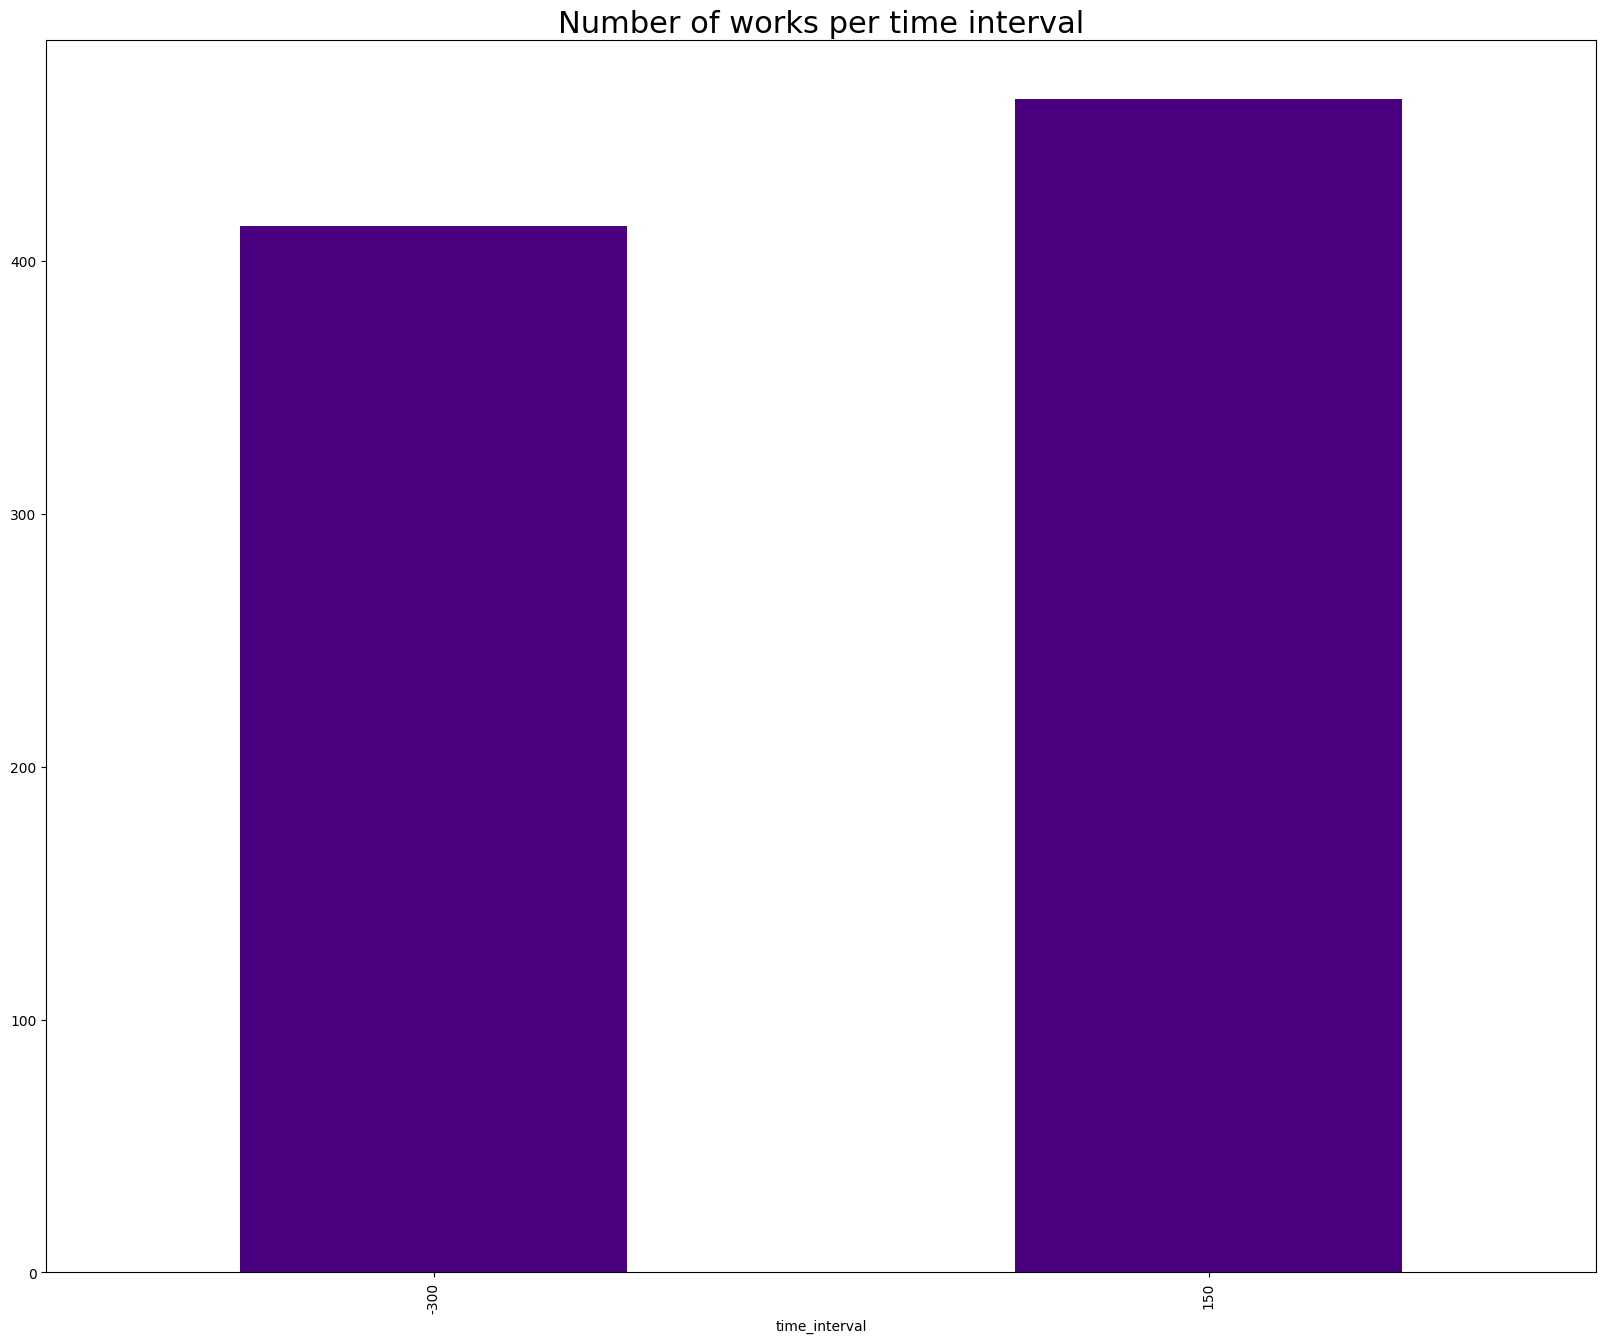

In [35]:
metadata_df0 = metadata_ph.groupby(['time_interval']).count()
metadata_df0 = metadata_df0['id']
ax = metadata_df0.plot(kind='bar', figsize=(20,16), color="indigo", fontsize=10);
ax.set_title("Number of works per time interval", fontsize=22)
plt.show()

### Define Christian vs non-Christian texts within second time slice (150-600 CE)

#### Christian subcorpus

Notes on which authors in IT corpus for Christian subcorpus (but should double-check if some texts need to be excluded within authors):

- 3rd century and earlier: Tertullian, Novatian, Minucius Felix, Arnobius, Lactantius, Commodian, Egeria
- 4-6th century: St Jerome, St Ambrose, St Augustine, Prudentius, Sedulius, Boethius (?), Sulpicius Severus, Prosper Aquitanus, Paulinus of Nola, Hydatius, Benedict of Nursia, Thomas of Edessa, Macarius of Alexandria, Eucherius of Lyon, Vincent de Lérins, Marcellinus Comes, Apophthegmata, Cassiodorus, Martin of Braga, Gregory of Tours, Isidore of Seville

**Look up LAT0435 and LAT0433 – they might need to be added to this list.**

Select Christian texts from IT:

In [36]:
tertullian = ['LAT0058', 'LAT0062','LAT0246', 'LAT0248', 'LAT0256', 'LAT0350', 'LAT0448', 'LAT0606', 'LAT0733', 'LAT0736', 'LAT0737', 'LAT0744', 'LAT0746', 'LAT0747', 'LAT0749', 'LAT0750', 'LAT0755', 'LAT0788']
novatian = ['LAT0865']
minucius_felix = ['LAT0267']
arnobius = ['LAT0264']
lactantius = ['LAT0268']
commodian = ['LAT0607']
egeria = ['LAT0719']
auctor_incertus_1 = ['LAT0471', 'LAT0203']
early_selected_texts = tertullian + novatian + minucius_felix + arnobius + lactantius + commodian + egeria + auctor_incertus_1
jerome1 = ['LAT0001', 'LAT0001_1', 'LAT0001_2', 'LAT0001_3', 'LAT0001_4', 'LAT0001_5', 'LAT0001_6', 'LAT0001_7', 'LAT0001_8', 'LAT0001_9', 'LAT0001_10', 'LAT0001_11', 'LAT0001_12', 'LAT0001_13', 'LAT0001_14', 'LAT0001_15', 'LAT0001_16', 'LAT0001_17', 'LAT0001_18', 'LAT0001_19', 'LAT0001_20', 'LAT0001_21', 'LAT0001_22', 'LAT0001_23', 'LAT0001_24', 'LAT0001_25', 'LAT0001_26', 'LAT0001_27', 'LAT0001_28', 'LAT0001_29', 'LAT0001_30', 'LAT0001_31', 'LAT0001_32', 'LAT0001_33', 'LAT0001_34', 'LAT0001_35']
jerome2 = ['LAT0001_36', 'LAT0001_37', 'LAT0001_38', 'LAT0001_39', 'LAT0001_40', 'LAT0001_41', 'LAT0001_42', 'LAT0001_43', 'LAT0001_44', 'LAT0001_45', 'LAT0001_46', 'LAT0001_47', 'LAT0001_48', 'LAT0001_49', 'LAT0001_50', 'LAT0001_51', 'LAT0001_52', 'LAT0001_53', 'LAT0001_54', 'LAT0001_55', 'LAT0001_56', 'LAT0001_57', 'LAT0001_58', 'LAT0001_59', 'LAT0001_60', 'LAT0001_61', 'LAT0001_62', 'LAT0001_63', 'LAT0001_64', 'LAT0001_65', 'LAT0001_66', 'LAT0001_67', 'LAT0001_68', 'LAT0001_69', 'LAT1039', 'LAT0726', 'LAT0843', 'LAT0878', 'LAT0880']
augustine = ['LAT0061', 'LAT0793', 'LAT0016', 'LAT0015', 'LAT0397', 'LAT0403', 'LAT0768']
ambrose = ['LAT0263', 'LAT0847']
paulinus_nola = ['LAT0609']
sulpicius_severus = ['LAT0612', 'LAT0410']
apophthegmata = ['LAT0978']
hydatius = ['LAT0775', 'LAT0776']
macarius_alex = ['LAT1004']
prudentius = ['LAT0270']
prosper_aquit = ['LAT0610']
sedulius = ['LAT0414']
eucherius_lyon = ['LAT0608']
vincent_lerins = ['LAT0904']
# boethius = ['LAT0917']
benedict_nursia = ['LAT0011']
cassiodorus = ['LAT0250', 'LAT0251', 'LAT0252', 'LAT0243', 'LAT0482']
thomas_edessa = ['LAT0875']
marcellinus_comes = ['LAT0791']
gregory_tours = ['LAT0783']
martin_braga = ['LAT0990', 'LAT0990_1', 'LAT0990_2', 'LAT0990_3', 'LAT0990_4', 'LAT0990_5', 'LAT0990_6', 'LAT0990_7', 'LAT0990_8', 'LAT0990_9']
isidore_seville = ['LAT0908', 'LAT0909', 'LAT0957']
auctor_incertus_2 = ['LAT0383']
late_selected_texts = jerome1 + jerome2 + augustine + ambrose + paulinus_nola + sulpicius_severus + apophthegmata + hydatius + macarius_alex + prudentius + prosper_aquit + sedulius + eucherius_lyon + vincent_lerins + benedict_nursia + cassiodorus + thomas_edessa + marcellinus_comes + gregory_tours + martin_braga + isidore_seville + auctor_incertus_2 # + boethius
selected_texts_1 = early_selected_texts + late_selected_texts
selected_texts_1 = ['IT-'+f for f in selected_texts_1]
selected_texts_1

['IT-LAT0058',
 'IT-LAT0062',
 'IT-LAT0246',
 'IT-LAT0248',
 'IT-LAT0256',
 'IT-LAT0350',
 'IT-LAT0448',
 'IT-LAT0606',
 'IT-LAT0733',
 'IT-LAT0736',
 'IT-LAT0737',
 'IT-LAT0744',
 'IT-LAT0746',
 'IT-LAT0747',
 'IT-LAT0749',
 'IT-LAT0750',
 'IT-LAT0755',
 'IT-LAT0788',
 'IT-LAT0865',
 'IT-LAT0267',
 'IT-LAT0264',
 'IT-LAT0268',
 'IT-LAT0607',
 'IT-LAT0719',
 'IT-LAT0471',
 'IT-LAT0203',
 'IT-LAT0001',
 'IT-LAT0001_1',
 'IT-LAT0001_2',
 'IT-LAT0001_3',
 'IT-LAT0001_4',
 'IT-LAT0001_5',
 'IT-LAT0001_6',
 'IT-LAT0001_7',
 'IT-LAT0001_8',
 'IT-LAT0001_9',
 'IT-LAT0001_10',
 'IT-LAT0001_11',
 'IT-LAT0001_12',
 'IT-LAT0001_13',
 'IT-LAT0001_14',
 'IT-LAT0001_15',
 'IT-LAT0001_16',
 'IT-LAT0001_17',
 'IT-LAT0001_18',
 'IT-LAT0001_19',
 'IT-LAT0001_20',
 'IT-LAT0001_21',
 'IT-LAT0001_22',
 'IT-LAT0001_23',
 'IT-LAT0001_24',
 'IT-LAT0001_25',
 'IT-LAT0001_26',
 'IT-LAT0001_27',
 'IT-LAT0001_28',
 'IT-LAT0001_29',
 'IT-LAT0001_30',
 'IT-LAT0001_31',
 'IT-LAT0001_32',
 'IT-LAT0001_33',
 'IT-LAT00

Notes on which authors in MQDQ corpus (but should double-check if some texts need to be excluded within authors):

Tertullian, Commodian, Lactantius, Laudes domini, Iuvencus, Proba, Marius Victorinus, Hilarius Pictaviensis, St Ambrose, Damasus, Prudentius, St Augustine, Paulinus of Nola, Pseudo Cyprian, Paulinus Pellaeus, Agrestius Gallus, Auspicius Tullensis, Carmen Sibyllinum, Cyprianus Gallus, Dracontius (partial), Paulinus Baeterrensis, Orientius, Paulinus Petricordiae, Prosper Aquitanus, Sedulius, Victorinus, Marius Victor, Sidonius Apollinaris, Ruricius Lemovicensis, Anonymous, Parthenius Africanus, Alcimus Avitus, Cyprianus Tolonensis, Remigius Remensis, Boethius (?), Ennodius, Arator, Flavius Cabilonensis, Marcus Casinensis, Rusticius Helpidius, Severus Malacitanus, Columba, Columbanus, Martin of Braga, Marius of Avenches, Isidor of Seville

Select Christian texts from MQDQ:

In [37]:
commodian = ['MQDQ-39', 'MQDQ-40', 'MQDQ-41']
tertullian = ['MQDQ-491', 'MQDQ-492']
lactantius = ['MQDQ-157', 'MQDQ-158', 'MQDQ-159']
laudes_dom = ['MQDQ-1']
iuvencus = ['MQDQ-151']
proba = ['MQDQ-350']
marius_vic = ['MQDQ-617']
hilarius_pic = ['MQDQ-117', 'MQDQ-118', 'MQDQ-119', 'MQDQ-120']
ambrose = ['MQDQ-179', 'MQDQ-180', 'MQDQ-181', 'MQDQ-182', 'MQDQ-183']
damasus = ['MQDQ-56']
prudentius = ['MQDQ-366', 'MQDQ-367', 'MQDQ-368', 'MQDQ-369', 'MQDQ-371', 'MQDQ-372', 'MQDQ-373', 'MQDQ-374', 'MQDQ-375']
augustine = ['MQDQ-512', 'MQDQ-513', 'MQDQ-514', 'MQDQ-515', 'MQDQ-516']
paulinus_nol = ['MQDQ-279', 'MQDQ-280', 'MQDQ-281', 'MQDQ-282']
pseud_cyp = ['MQDQ-379', 'MQDQ-380', 'MQDQ-381', 'MQDQ-382', 'MQDQ-383']
paulinus_pel = ['MQDQ-283', 'MQDQ-284']
agrestius_gal = ['MQDQ-66']
auspicius_tul = ['MQDQ-608']
carmen_sib = ['MQDQ-5']
cyprian_gal = ['MQDQ-48', 'MQDQ-49', 'MQDQ-50', 'MQDQ-51', 'MQDQ-52', 'MQDQ-53', 'MQDQ-54', 'MQDQ-55']
dracontius = ['MQDQ-59', 'MQDQ-60']
paulinus_bae = ['MQDQ-278']
orientius = ['MQDQ-242', 'MQDQ-243']
paulinus_pet = ['MQDQ-285', 'MQDQ-286', 'MQDQ-287']
prosper_aqu = ['MQDQ-360', 'MQDQ-361', 'MQDQ-362', 'MQDQ-363', 'MQDQ-364', 'MQDQ-365']
sedulius = ['MQDQ-422', 'MQDQ-423']
victorinus = ['MQDQ-564', 'MQDQ-565', 'MQDQ-566']
marius_vic = ['MQDQ-189']
sidonius = ['MQDQ-444', 'MQDQ-445']
ruricius_lem = ['MQDQ-111']
anonymous = ['MQDQ-140']
parthenius_afr = ['MQDQ-277']
alcimus_avi = ['MQDQ-622', 'MQDQ-623']
cyprianus_tol = ['MQDQ-621']
remigius_rem = ['MQDQ-618']
gildas = ['MQDQ-574', 'MQDQ-575']
# boethius = ['MQDQ-627', 'MQDQ-628']
ennodius = ['MQDQ-75', 'MQDQ-76', 'MQDQ-77', 'MQDQ-78', 'MQDQ-79', 'MQDQ-80', 'MQDQ-81', 'MQDQ-82', 'MQDQ-83', 'MQDQ-84', 'MQDQ-85', 'MQDQ-86']
arator = ['MQDQ-351', 'MQDQ-352', 'MQDQ-353', 'MQDQ-354', 'MQDQ-355']
flavius_cab = ['MQDQ-95']
marcus_cas = ['MQDQ-244']
rusticius_hel = ['MQDQ-415', 'MQDQ-416']
severus_mal = ['MQDQ-191']
columba = ['MQDQ-619']
columbanus = ['MQDQ-30', 'MQDQ-31', 'MQDQ-32', 'MQDQ-33', 'MQDQ-34', 'MQDQ-35']
martin_bra = ['MQDQ-209', 'MQDQ-210', 'MQDQ-211']
marius_ave = ['MQDQ-188']
isidore_sev = ['MQDQ-148']
selected_texts_2 = commodian + tertullian + lactantius + laudes_dom + iuvencus + proba + marius_vic + hilarius_pic + ambrose + damasus + prudentius + augustine + paulinus_nol + pseud_cyp + paulinus_pel + agrestius_gal + auspicius_tul + carmen_sib + cyprian_gal + dracontius + paulinus_bae + orientius + paulinus_pet + prosper_aqu + sedulius + victorinus + sidonius + ruricius_lem + anonymous + parthenius_afr + alcimus_avi + cyprianus_tol + remigius_rem + gildas + ennodius + arator + flavius_cab + marcus_cas + rusticius_hel + severus_mal + columba + columbanus + martin_bra + marius_ave + isidore_sev
selected_texts_2

['MQDQ-39',
 'MQDQ-40',
 'MQDQ-41',
 'MQDQ-491',
 'MQDQ-492',
 'MQDQ-157',
 'MQDQ-158',
 'MQDQ-159',
 'MQDQ-1',
 'MQDQ-151',
 'MQDQ-350',
 'MQDQ-189',
 'MQDQ-117',
 'MQDQ-118',
 'MQDQ-119',
 'MQDQ-120',
 'MQDQ-179',
 'MQDQ-180',
 'MQDQ-181',
 'MQDQ-182',
 'MQDQ-183',
 'MQDQ-56',
 'MQDQ-366',
 'MQDQ-367',
 'MQDQ-368',
 'MQDQ-369',
 'MQDQ-371',
 'MQDQ-372',
 'MQDQ-373',
 'MQDQ-374',
 'MQDQ-375',
 'MQDQ-512',
 'MQDQ-513',
 'MQDQ-514',
 'MQDQ-515',
 'MQDQ-516',
 'MQDQ-279',
 'MQDQ-280',
 'MQDQ-281',
 'MQDQ-282',
 'MQDQ-379',
 'MQDQ-380',
 'MQDQ-381',
 'MQDQ-382',
 'MQDQ-383',
 'MQDQ-283',
 'MQDQ-284',
 'MQDQ-66',
 'MQDQ-608',
 'MQDQ-5',
 'MQDQ-48',
 'MQDQ-49',
 'MQDQ-50',
 'MQDQ-51',
 'MQDQ-52',
 'MQDQ-53',
 'MQDQ-54',
 'MQDQ-55',
 'MQDQ-59',
 'MQDQ-60',
 'MQDQ-278',
 'MQDQ-242',
 'MQDQ-243',
 'MQDQ-285',
 'MQDQ-286',
 'MQDQ-287',
 'MQDQ-360',
 'MQDQ-361',
 'MQDQ-362',
 'MQDQ-363',
 'MQDQ-364',
 'MQDQ-365',
 'MQDQ-422',
 'MQDQ-423',
 'MQDQ-564',
 'MQDQ-565',
 'MQDQ-566',
 'MQDQ-444',
 'MQD

Merge Christian texts from IT and MQDQ:

In [38]:
selected_texts = selected_texts_1 + selected_texts_2
len(selected_texts)

267

Print christian metadata to csv:

In [39]:
metadata_ph_christian = metadata_ph[(metadata_ph['id'].isin(selected_texts))]
metadata_ph_christian
metadata_ph_christian.to_csv(os.path.join(dir_out, 'csv', 'metadata_christian.csv'), index=None)

#### Non-Christian subcorpus

Select post 150 CE non-Christian texts by exclusion and display metadata:

In [40]:
metadata_ph_nonchristian = metadata_ph[(metadata_ph['time_interval']==150) & (~metadata_ph['id'].isin(selected_texts))]
metadata_ph_nonchristian

,id,title,creator,date,type,file,time_interval
421,IT-LAT0360,Noctes Atticae,"Gellius, Aulus",150,prose,lat_0150_IT-LAT0360.txt,150
422,IT-LAT0406,De nugis philosophorum,"Balbus, [Pseudo-] Caecilius",150,prose,lat_0150_IT-LAT0406.txt,150
423,IT-LAT0407,Quaestiones,"Caecilius Africanus, Sextus",150,prose,lat_0150_IT-LAT0407.txt,150
424,IT-LAT0916,De verbis dubiis,"Caper, Flavius",150,prose,lat_0150_IT-LAT0916.txt,150
425,MQDQ-223,carminum fragmenta,Annianus,150,poetry,lat_0150.0_MQDQ-223.txt,150
...,...,...,...,...,...,...,...
869,MQDQ-347,carmen in laudem Anastasii imperatoris,Priscianus,550,poetry,lat_0550.0_MQDQ-347.txt,150
870,MQDQ-348,carminis fragmentum,Priscianus,550,poetry,lat_0550.0_MQDQ-348.txt,150
871,MQDQ-346,perihegesis,Priscianus,550,poetry,lat_0550.0_MQDQ-346.txt,150
875,MQDQ-475,sylloge cod. Elnonensis,sylloge cod. Elnonensis,550,poetry,lat_0550.0_MQDQ-475.txt,150


In [41]:
nonchristian_selected_texts = list(metadata_ph_nonchristian['id'])
nonchristian_selected_texts

['IT-LAT0360',
 'IT-LAT0406',
 'IT-LAT0407',
 'IT-LAT0916',
 'MQDQ-223',
 'MQDQ-490',
 'MQDQ-240',
 'MQDQ-293',
 'MQDQ-345',
 'MQDQ-470',
 'MQDQ-465',
 'MQDQ-471',
 'MQDQ-467',
 'MQDQ-466',
 'MQDQ-469',
 'MQDQ-472',
 'MQDQ-468',
 'IT-LAT0043',
 'MQDQ-540',
 'IT-LAT0201',
 'IT-LAT0204',
 'IT-LAT0621',
 'IT-LAT0665',
 'IT-LAT0846',
 'IT-LAT0913',
 'IT-LAT0914',
 'MQDQ-123',
 'MQDQ-138',
 'MQDQ-234',
 'MQDQ-233',
 'MQDQ-232',
 'MQDQ-343',
 'MQDQ-344',
 'MQDQ-558',
 'IT-LAT0893',
 'IT-LAT0895',
 'IT-LAT0896',
 'IT-LAT0351',
 'MQDQ-107',
 'MQDQ-447',
 'MQDQ-87',
 'MQDQ-241',
 'MQDQ-290',
 'MQDQ-377',
 'MQDQ-378',
 'MQDQ-393',
 'MQDQ-499',
 'MQDQ-500',
 'MQDQ-563',
 'IT-LAT0886',
 'MQDQ-166',
 'MQDQ-149',
 'IT-LAT0115',
 'IT-LAT0233',
 'IT-LAT0238',
 'IT-LAT0286',
 'IT-LAT0353',
 'IT-LAT0361',
 'IT-LAT0362',
 'IT-LAT0364',
 'IT-LAT0365',
 'IT-LAT0366',
 'IT-LAT0367',
 'IT-LAT0850',
 'IT-LAT0919',
 'MQDQ-569',
 'MQDQ-570',
 'MQDQ-571',
 'MQDQ-573',
 'MQDQ-10',
 'MQDQ-609',
 'MQDQ-192',
 'MQDQ

## Make corpus and subcorpora

### Whole corpus

Define punctuation for stripping from corpus:

In [42]:
punctuation = ['.', ',', '...', ';', ':', '?', '(', ')', '-', '!', '[', ']', '"', "'", '""', '\n', '']

Append all files:

In [43]:
# Outputs a list of lists
corpus = list()
files_corpus = metadata_ph
for index, df_line in files_corpus.iterrows():
    sign = "+"
    if df_line['date'] < 0:
        sign = "-"
    file_name = df_line['file']
    file = open(os.path.join(os.path.dirname(dir_in), "data", "new_lemmatized_texts", file_name), 'r')
    while True:
        line = file.readline().strip()
        if line != "":
            corpus.append([token.lower() for token in line.split(" ") if token not in punctuation])
        if not line:
            break
    file.close()

### Time subcorpora

In [44]:
time2corpus = dict()

# Loop over all time intervals:
for t in range(n_intervals+1):
    files_corpus_t = metadata_ph.loc[metadata_ph['time_interval'] == intervals[t]]
    corpus_t = list()
    for index, df_line in files_corpus_t.iterrows():
        sign = "+"
        if df_line['date'] < 0:
            sign = "-"
        file_name = df_line['file']
        file = open(os.path.join(os.path.dirname(dir_in), "data", "new_lemmatized_texts", file_name), 'r')
        sentences_this_file = list()
        while True:
            line = file.readline().strip()
            if line != "":
                corpus_t.append([token.lower() for token in line.split(" ") if token not in punctuation])
            # if line is empty end of file is reached
            if not line:
                break
        file.close()
    time2corpus[t] = corpus_t

Check sentence and token balance between the two time slices:

In [45]:
# Number of sentences in the first time interval
len(time2corpus[0])

204522

In [46]:
# Number of words in the first time interval
num_words_int_0 = sum(len(i) for i in time2corpus[0])
num_words_int_0

3704745

In [47]:
# Number of sentences in the second time interval
len(time2corpus[1])

216777

In [48]:
# Number of words in the second time interval
num_words_int_1 = sum(len(i) for i in time2corpus[1])
num_words_int_1

3110871

In [49]:
# Sentence count ratio
len(time2corpus[0])/len(time2corpus[1])

0.9434672497543558

In [50]:
# Word count ratio
num_words_int_0/num_words_int_1

1.1909028050343458

Plot token count:

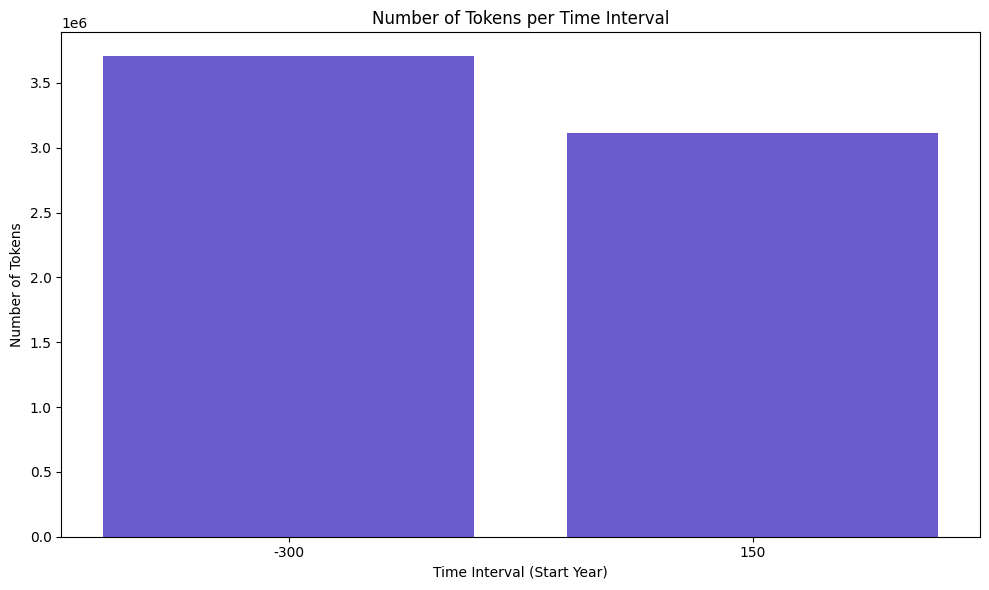

In [51]:
labels = ['-300', '150']
counts = [num_words_int_0, num_words_int_1]

plt.figure(figsize=(10,6))
plt.bar(labels, counts, color='slateblue')
plt.xlabel('Time Interval (Start Year)')
plt.ylabel('Number of Tokens')
plt.title('Number of Tokens per Time Interval')
plt.tight_layout()
plt.show()

### (Non-)Christian subcorpora

In [52]:
corpus_christi = list()
files_corpus_christi = metadata_ph_christian
for index, df_line in files_corpus_christi.iterrows():
    sign = "+"
    if df_line['date'] < 0:
        sign = "-"
    file_name = df_line['file']
    file = open(os.path.join(os.path.dirname(dir_in), "data", "new_lemmatized_texts", file_name), 'r')
    sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            corpus_christi.append([token.lower() for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
corpus_christi.append(sentences_this_file)

In [53]:
corpus_non_christi = list()
files_corpus_non_christi = metadata_ph_nonchristian
for index, df_line in files_corpus_non_christi.iterrows():
    sign = "+"
    if df_line['date'] < 0:
        sign = "-"
    file_name = df_line['file'] 
    file = open(os.path.join(os.path.dirname(dir_in), "data", "new_lemmatized_texts", file_name), 'r')
    sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            corpus_non_christi.append([token.lower() for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
corpus_non_christi.append(sentences_this_file)

Check sentence and token balance between the two subcorpora:

In [54]:
len(corpus_christi)

98274

In [55]:
num_words_corpus_christi = sum(len(i) for i in corpus_christi)
num_words_corpus_christi

1740382

In [56]:
len(corpus_non_christi)

118505

In [57]:
num_words_corpus_non_christi = sum(len(i) for i in corpus_non_christi)
num_words_corpus_non_christi

1370489

In [58]:
len(corpus_christi)/len(corpus_non_christi)

0.8292814649170921

In [59]:
num_words_corpus_christi/num_words_corpus_non_christi

1.2698985544575696

Plot token count:

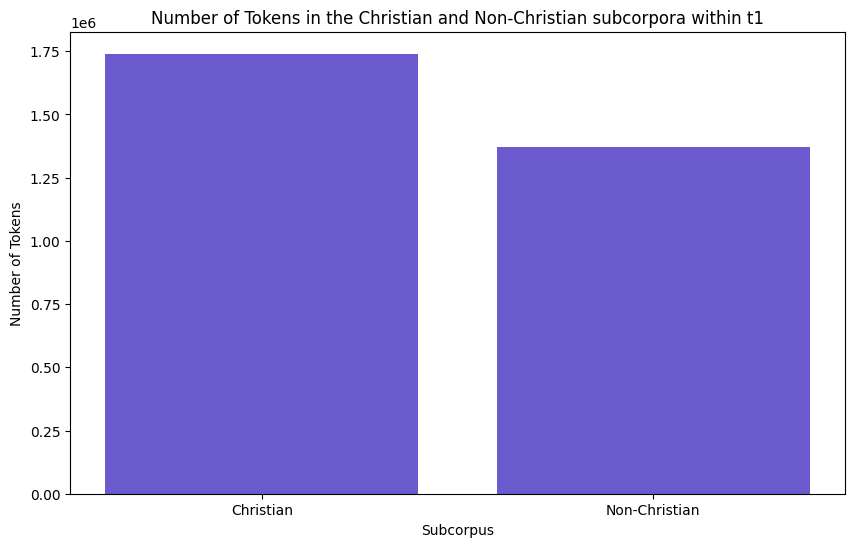

In [60]:
labels = ['Christian', 'Non-Christian']
counts = [num_words_corpus_christi, num_words_corpus_non_christi]

plt.figure(figsize=(10,6))
plt.bar(labels, counts, color='slateblue')
plt.xlabel('Subcorpus')
plt.ylabel('Number of Tokens')
plt.title('Number of Tokens in the Christian and Non-Christian subcorpora within t1')
plt.show()

## Pre-trained LatinBERT 

Remember to set `rebuild` to `True` or `False` as needed before averaging and clustering embeddings.

### Load embeddings

First time slice (300 BCE to 180 CE):

In [17]:
berts_t0 = load_embeddings_h5("berts_pretrained_pre_180.h5", dir_emb_pretrained, batch_size=1000)

Loading embeddings from /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/embeddings_pretrained/berts_pretrained_pre_180.h5 in batches...


Second time slice (180 to 605 CE):

In [18]:
berts_t1 = load_embeddings_h5("berts_pretrained_post_180.h5", dir_emb_pretrained, batch_size=1000)

Loading embeddings from /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/embeddings_pretrained/berts_pretrained_post_180.h5 in batches...


### Average embeddings per lemma and use similarity measurements on averages

#### Averaging operation

Starting with the first time slice:

In [ ]:
average_embeddings_t0, most_frequent_words_t0 = average_embeddings_by_lemma(berts_t0, dir_avg_emb_pretrained, "average_embeddings_t0", rebuild)

Average embeddings saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/avg_emb_pretrained/average_embeddings_t0.pickle.h5
Word: magnus
Count: 11569
Top surface forms: [('magna', 1684), ('magno', 1129), ('maior', 816), ('magnum', 639), ('maxima', 553)]
Embedding: [-1.27564181e-03 -3.75164934e-02  4.63036550e-02 -1.69740448e-02
  2.11159877e-02 -1.54027198e-02  1.76515106e-03 -2.21713236e-03
 -1.51104902e-02  6.55910160e-03 -3.65552036e-03  1.52887266e-02
 -1.35136124e-02 -2.88041119e-02  2.74146069e-02  1.70813551e-02
 -1.76852649e-02  1.95356889e-03  4.21754765e-03  3.72582976e-02
 -8.62408092e-03 -4.85885645e-02 -6.14474469e-02 -1.57052078e-03
 -7.44436269e-03 -1.60230808e-03 -1.70377624e-03  2.90095421e-02
  7.42446743e-02 -6.49933526e-03 -1.24471759e-02  6.71361477e-03
 -5.19881883e-02 -6.49401644e-02  8.59886313e-03  1.95527878e-03
  1.43036345e-02 -7.72139762e-04  8.49897282e-03  2.93073693e-02
  1.57534524e-02 -1.05709709e

And following with the second time slice:

In [ ]:
average_embeddings_t1, most_frequent_words_t1 = average_embeddings_by_lemma(berts_t1, dir_avg_emb_pretrained, "average_embeddings_t1", rebuild)

Average embeddings saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/avg_emb_pretrained/average_embeddings_t1.pickle.h5
Word: deus
Count: 15552
Top surface forms: [('Deus', 3016), ('Dei', 2792), ('deus', 1510), ('dei', 1406), ('Deo', 1392)]
Embedding: [ 3.05947223e-02  1.34116396e-02 -1.49094567e-02  2.85008531e-02
 -3.25030375e-02 -2.00214013e-02 -1.52716088e-02 -6.32677734e-02
 -3.78892335e-02  2.02553348e-02  3.87799415e-04  5.86139478e-03
 -2.85877766e-02  8.30896832e-03  1.48571378e-02  3.83050803e-02
  3.84765249e-03  1.62817558e-02 -3.44530863e-02  2.43190302e-02
  1.55016812e-03 -5.58619501e-02 -6.45257196e-02  2.63537471e-02
  1.62655592e-02  6.79363407e-04 -3.80629983e-02 -1.56846721e-03
  5.66220502e-02  1.65662376e-02 -3.01599818e-02  2.22529818e-03
 -4.31211047e-02 -4.45530819e-02  3.82339782e-03  1.80847713e-02
 -1.24795884e-02 -2.29828902e-02  3.48265066e-02  1.96475771e-02
  2.40623227e-02 -2.07888158e-02 -4.77

Sanity check: print the 500 most common words in t0 and t1

In [49]:
# Dictionary to store embeddings for each word type
word_embeddings = defaultdict(list)
word_counter = Counter()
    
# Collect all embeddings for each word type and count word frequencies
for record in berts_t0:
    for token in record["tokens"]:
        lemma = token["lemma"]
        embedding = token["embedding"]
        word_embeddings[lemma].append(embedding)
        word_counter[lemma] += 1

# Get the 500 most frequent words
most_frequent_words_t0 = [word for word, _ in word_counter.most_common(500)]

# Print the embeddings for the ten most frequent words
for word in most_frequent_words_t0:
    print(f"Word: {word}")

Word: magnus
Word: animus
Word: pater
Word: uolo
Word: pars
Word: homo
Word: unus
Word: locus
Word: romanus
Word: bellum
Word: dies
Word: ago
Word: primus
Word: uenio
Word: tempus
Word: urbs
Word: hostis
Word: deus
Word: bonus
Word: uir
Word: consul
Word: populus
Word: uis
Word: corpus
Word: modus
Word: manus
Word: publicus
Word: rex
Word: genus
Word: nomen
Word: totus
Word: arma
Word: iubeo
Word: terra
Word: mitto
Word: miles
Word: peto
Word: senatus
Word: uerbum
Word: credo
Word: duo
Word: capio
Word: quaero
Word: domus
Word: annus
Word: puto
Word: uita
Word: uirtus
Word: lex
Word: exercitus
Word: sequor
Word: audio
Word: scio
Word: os
Word: accipio
Word: castra
Word: teneo
Word: pono
Word: opus
Word: debeo
Word: ratio
Word: natura
Word: duco
Word: ius
Word: caesar
Word: nouus
Word: fortuna
Word: gero
Word: mille
Word: mors
Word: uinco
Word: relinquo
Word: paruus
Word: medius
Word: dux
Word: ager
Word: consilium
Word: nox
Word: refero
Word: caput
Word: fides
Word: uox
Word: signum
Wo

In [50]:
# Dictionary to store embeddings for each word type
word_embeddings = defaultdict(list)
word_counter = Counter()
    
# Collect all embeddings for each word type and count word frequencies
for record in berts_t1:
    for token in record["tokens"]:
        lemma = token["lemma"]
        embedding = token["embedding"]
        word_embeddings[lemma].append(embedding)
        word_counter[lemma] += 1

# Get the 500 most frequent words
most_frequent_words_t1 = [word for word, _ in word_counter.most_common(500)]

# Print the embeddings for the ten most frequent words
for word in most_frequent_words_t1:
    print(f"Word: {word}")

Word: deus
Word: dominus
Word: dies
Word: filius
Word: cio
Word: rex
Word: homo
Word: pater
Word: magnus
Word: terra
Word: unus
Word: uenio
Word: locus
Word: tempus
Word: nomen
Word: pars
Word: uolo
Word: conss
Word: uir
Word: populus
Word: imperator
Word: manus
Word: uerbum
Word: kalendae
Word: corpus
Word: lex
Word: domus
Word: christus
Word: annus
Word: primus
Word: sanctus
Word: credo
Word: uita
Word: debeo
Word: totus
Word: imperatores
Word: mors
Word: ago
Word: ius
Word: mitto
Word: audio
Word: bonus
Word: accipio
Word: fides
Word: pono
Word: loquor
Word: frater
Word: duo
Word: os
Word: urbs
Word: liber
Word: solus
Word: cunctus
Word: caelum
Word: anima
Word: ciuitas
Word: uis
Word: bellum
Word: gens
Word: iubeo
Word: teneo
Word: mater
Word: uox
Word: genus
Word: inuenio
Word: opus
Word: scio
Word: modus
Word: animus
Word: caput
Word: uoco
Word: uirtus
Word: regnum
Word: peto
Word: quaero
Word: ratio
Word: mens
Word: aqua
Word: sequor
Word: cc
Word: cor
Word: capio
Word: spiritus

#### Cosine similarity and PRT

Now find cosine similarity between the averaged vectors of t0 and t1.

In [24]:
# Compute cosine similarity for each token that appears in both t0 and t1
cosine_similarities_t0t1 = {}
for token in average_embeddings_t0:
    if token in average_embeddings_t1:
        embedding_t0 = average_embeddings_t0[token].reshape(1, -1)
        embedding_t1 = average_embeddings_t1[token].reshape(1, -1)
        similarity = cosine_similarity(embedding_t0, embedding_t1)[0][0]
        cosine_similarities_t0t1[token] = similarity

# Sort by similarity value (descending)
sorted_similarities = sorted(cosine_similarities_t0t1.items(), key=lambda x: x[1], reverse=True)

# Print the sorted cosine similarities
for token, similarity in sorted_similarities:
    print(f"Token: {token}, Cosine Similarity: {similarity}")   

Token: graecia, Cosine Similarity: 0.9969632697007315
Token: phoebus, Cosine Similarity: 0.9968662188647633
Token: nilus, Cosine Similarity: 0.9963548734571014
Token: athenienses, Cosine Similarity: 0.9957307739688278
Token: parthi, Cosine Similarity: 0.9954481870084666
Token: cicero, Cosine Similarity: 0.9951276219391296
Token: caesar, Cosine Similarity: 0.995123244136848
Token: pythagoras, Cosine Similarity: 0.9949898116502363
Token: persa, Cosine Similarity: 0.9949886645143197
Token: asia, Cosine Similarity: 0.9949753869602516
Token: thracia, Cosine Similarity: 0.9949328961209363
Token: athenae, Cosine Similarity: 0.9948383513535157
Token: olympus, Cosine Similarity: 0.9948112284464324
Token: aruum, Cosine Similarity: 0.9948095882911205
Token: lacedaemonii, Cosine Similarity: 0.9947091886841878
Token: musa, Cosine Similarity: 0.9946865126287512
Token: uicinus, Cosine Similarity: 0.9946855593090543
Token: tonans, Cosine Similarity: 0.9945681773626627
Token: nereus, Cosine Similarity:

In [27]:
# Write the cosine similarities to a CSV file
cosine_sim_csv = os.path.join(dir_out, "csv", "cosine_similarities_t0t1.csv")

with open(cosine_sim_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Token", "Cosine Similarity"])  # Write the header
    for token, similarity in cosine_similarities_t0t1.items():
        writer.writerow([token, similarity])

print(f"Cosine similarities saved to {cosine_sim_csv}")

Cosine similarities saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/csv/cosine_similarities_t0t1.csv


Note: there is also **PRT**, a.k.a. inverted cosine similarity over word prototypes – meaning over embeddings averaged by token or lemma (across the different corpora). The only difference is that, as per the definition, it's 1 / cosine similarity. There is some evidence that it yields slighly better results than cosine similarity by itself.

Calculate it for average embeddings between t0 and t1:

In [ ]:
# Compute PRT values from cosine similarities
prt_t0t1 = {}
for token, similarity in cosine_similarities_t0t1.items():
    prt_t0t1[token] = 1 / similarity if similarity != 0 else float('inf')

# Sort by PRT value (ascending: higher means more change)
sorted_prt = sorted(prt_t0t1.items(), key=lambda x: x[1], reverse=False)

# Print the sorted PRT values
for token, prt_value in sorted_prt:
    print(f"Token: {token}, PRT: {prt_value}")

Token: graecia, PRT: 1.003045980119388
Token: phoebus, PRT: 1.0031436325917489
Token: nilus, PRT: 1.0036584621002063
Token: athenienses, PRT: 1.004287530467855
Token: parthi, PRT: 1.0045726267333035
Token: cicero, PRT: 1.004896234365775
Token: caesar, PRT: 1.0049006551619462
Token: pythagoras, PRT: 1.005035416736031
Token: persa, PRT: 1.0050365754549841
Token: asia, PRT: 1.005049987271644
Token: thracia, PRT: 1.005092910184013
Token: athenae, PRT: 1.0051884294965727
Token: olympus, PRT: 1.0052158353315641
Token: aruum, PRT: 1.0052174926437887
Token: lacedaemonii, PRT: 1.0053189528919613
Token: musa, PRT: 1.0053418713371376
Token: uicinus, PRT: 1.0053428348699838
Token: tonans, PRT: 1.0054614884740642
Token: nereus, PRT: 1.005494568324516
Token: caterua, PRT: 1.0055153315097838
Token: frango, PRT: 1.0055185021771031
Token: libya, PRT: 1.0055241598151423
Token: lacedaemonius, PRT: 1.005526689361688
Token: uestigium, PRT: 1.005542942332226
Token: graecus, PRT: 1.005550284999663
Token: pyr

In [26]:
# Write the PRT values to a CSV file
prt_csv = os.path.join(dir_out, "csv", "prt_t0t1.csv")

with open(prt_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Token", "PRT"])  # Write the header
    for token, similarity in prt_t0t1.items():
        writer.writerow([token, similarity])

print(f"PRT values saved to {prt_csv}")

PRT values saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/csv/prt_t0t1.csv


#### A function showing us neighbors (as you'd try and find for static embeddings)

Check neighbours for some of the words in the various subcorpora:

In [28]:
neighbors = find_neighbors("deus", average_embeddings_t0, top_k=10)
print(neighbors)

[('dea', np.float64(0.8754261440866344)), ('numen', np.float64(0.8274723506800368)), ('diuus', np.float64(0.8187313677475827)), ('religio', np.float64(0.7996458470085818)), ('superi', np.float64(0.7916333024641766)), ('caelestis', np.float64(0.7909494828060669)), ('dius', np.float64(0.7848403504845192)), ('sacerdos', np.float64(0.7844810790065829)), ('diuinus', np.float64(0.7793282164494755)), ('sacer', np.float64(0.7768060000108105))]


In [29]:
neighbors = find_neighbors("deus", average_embeddings_t1, top_k=10)
print(neighbors)

[('dominus', np.float64(0.9042209686957166)), ('iudaeus', np.float64(0.8854717174718649)), ('hebraei', np.float64(0.876241380774696)), ('nazarenus', np.float64(0.8732720346099072)), ('hebraeus', np.float64(0.87083300202572)), ('diana', np.float64(0.8643006563150658)), ('delius', np.float64(0.8634004408042039)), ('damascus', np.float64(0.8631006297200434)), ('dido', np.float64(0.8629902023504055)), ('hercules', np.float64(0.8617419836237965))]


In [30]:
neighbors = find_neighbors("dominus", average_embeddings_t0, top_k=10)
print(neighbors)

[('domina', np.float64(0.8940042324583881)), ('dominium', np.float64(0.8298265687420312)), ('liber', np.float64(0.8195614819608077)), ('custos', np.float64(0.8191111424091337)), ('libertas', np.float64(0.8139516285475898)), ('procurator', np.float64(0.8106601620176109)), ('pastor', np.float64(0.8056189147071074)), ('pretium', np.float64(0.8018873137495064)), ('patronus', np.float64(0.7969896817434334)), ('latro', np.float64(0.7959937977443277))]


In [31]:
neighbors = find_neighbors("dominus", average_embeddings_t1, top_k=10)
print(neighbors)

[('deus', np.float64(0.9042209686957166)), ('dominica', np.float64(0.897892025224106)), ('donatus', np.float64(0.8913861969426162)), ('domitianus', np.float64(0.8912723398859189)), ('damasus', np.float64(0.8905396141500221)), ('deuteronomius', np.float64(0.890024960058741)), ('iordanes', np.float64(0.8890092580122846)), ('iohannes', np.float64(0.8869402933469419)), ('paulus', np.float64(0.8848684967852387)), ('libanus', np.float64(0.8847289726708836))]


In [32]:
neighbors = find_neighbors("uirtus", average_embeddings_t0, top_k=10)
print(neighbors)

[('honestas', np.float64(0.881320929049746)), ('claritas', np.float64(0.8650966883047551)), ('probitas', np.float64(0.8622132408736866)), ('nequitia', np.float64(0.8603672561473384)), ('uictoria', np.float64(0.8559100412098065)), ('aequitas', np.float64(0.8546788687285396)), ('liberalitas', np.float64(0.8538138582026891)), ('laudabilis', np.float64(0.8466978750703344)), ('benignitas', np.float64(0.844061117327375)), ('indoles', np.float64(0.8413901435225868))]


In [33]:
neighbors = find_neighbors("uirtus", average_embeddings_t1, top_k=10)
print(neighbors)

[('honestas', np.float64(0.8768693084512925)), ('maiestas', np.float64(0.8765835538485167)), ('uictoria', np.float64(0.8633885309384723)), ('claritas', np.float64(0.8541584738066069)), ('castitas', np.float64(0.854157948631172)), ('benignitas', np.float64(0.8533252609711875)), ('palma', np.float64(0.85151132075949)), ('laudabilis', np.float64(0.8488765640518455)), ('uis', np.float64(0.8476684299429184)), ('excello', np.float64(0.8463832697949956))]


In [85]:
neighbors = find_neighbors("nepos", average_embeddings_t0, top_k=10)
print(neighbors)

[('gener', np.float64(0.8883967163453652)), ('parens', np.float64(0.8820532828870778)), ('frater', np.float64(0.8574650113462021)), ('natus', np.float64(0.8504777949611217)), ('auus', np.float64(0.844503362014225)), ('filia', np.float64(0.8425486809199424)), ('soror', np.float64(0.8392081292659894)), ('successor', np.float64(0.8357134482929196)), ('nascor', np.float64(0.8348856949247168)), ('filius', np.float64(0.8341088023421133))]


In [86]:
neighbors = find_neighbors("nepos", average_embeddings_t1, top_k=10)
print(neighbors)

[('gener', np.float64(0.8548963211209264)), ('geno', np.float64(0.8446779646969139)), ('filia', np.float64(0.8444855710370002)), ('genero', np.float64(0.8419528790573133)), ('auus', np.float64(0.8404302866046467)), ('proles', np.float64(0.8393445905429426)), ('parens', np.float64(0.8355615324718468)), ('frater', np.float64(0.8335077125876236)), ('successor', np.float64(0.8286411927376232)), ('pater', np.float64(0.8260202497357717))]


Try to plot target average embeddings with their neighbors:

Plot saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/PCA/neighbors_nepos.png


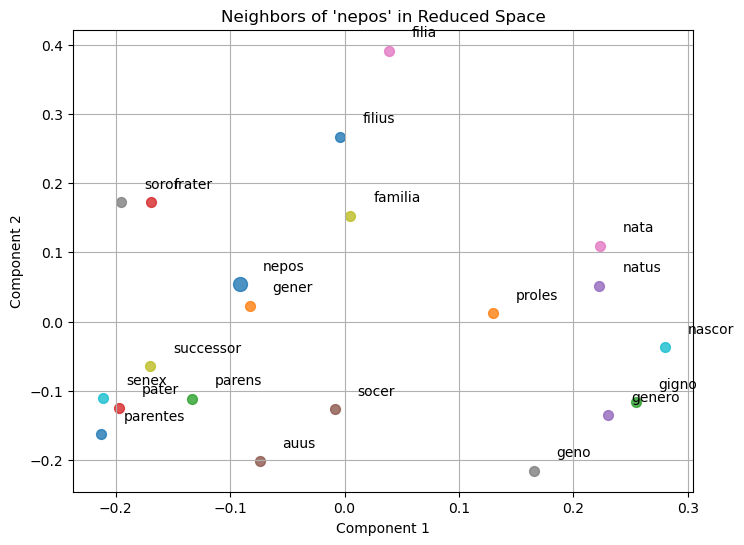

In [87]:
# Example: Plot neighbors of "nepos"
neighbors = find_neighbors("nepos", average_embeddings_t0, top_k=20)
plot_neighbors("nepos", neighbors, average_embeddings_t0, output_dir=os.path.join(dir_out, "PCA")) # if you don't want to save the plot, delete the output_dir argument

Plot saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/PCA/neighbors_nepos.png


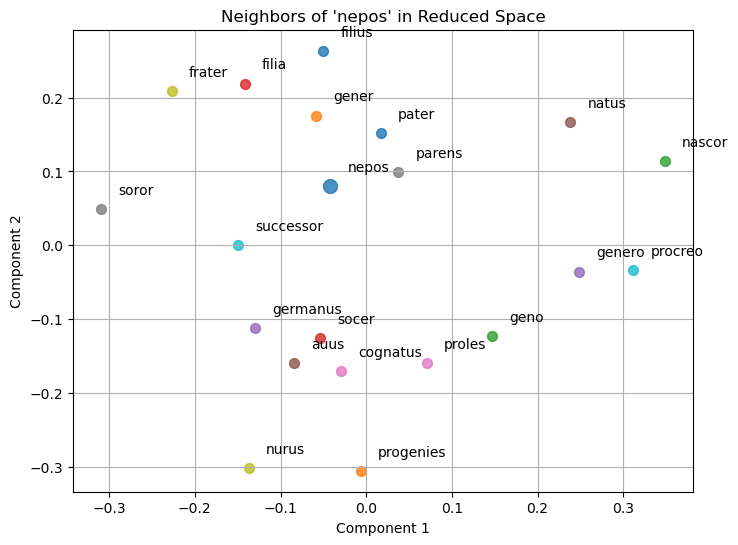

In [88]:
# Example: Plot neighbors of "nepos"
neighbors = find_neighbors("nepos", average_embeddings_t1, top_k=20)
plot_neighbors("nepos", neighbors, average_embeddings_t1, output_dir=os.path.join(dir_out, "PCA")) # if you don't want to save the plot, delete the output_dir argument

In [ ]:
# Change list of words and filename as needed
save_neighbors(
    word_list=["deus", "dominus", "uirtus"],
    average_embeddings=average_embeddings_t1,
    top_k=10,
    output_dir=os.path.join(dir_out, "csv"),
    output_filename="neighbors_t1.csv"
)

#### A different method for measuring: APD, or average pairwise cosine distance

Average Pairwise Distance (APD) measures semantic change by computing the average distance (cosine or euclidean, but cosine here) between all possible pairs of contextualized embeddings of a word across two time slices or corpora. Thus, APD does not require any aggregation or clustering. It reflects the variance in word meaning by directly comparing token-level embeddings.

In [106]:
# Define terms of interest
# christian_terms = ["scriptura", "lectio", "deus", "dominus", "creator", "factor", "deductor", "oratio", "lex", "altarium", "tabernaculum", "memoria", "recessus", "frater", "soror", "canticum", "virtus", "gratia", "gloria", "panis", "anima","sanctus", "beatus"]
changed_lemmas = [
    "beatus", "ciuitas", "cohors", "consul", "credo", "dolus", "dux",
    "fidelis", "humanitas", "imperator", "itero", "pontifex",
    "potestas", "sacramentum", "sanctus", "scriptura", "uirtus"
]

# Extract embeddings for the selected terms from both time points
selected_word_embeddings_t0 = extract_selected_embeddings(berts_t0, changed_lemmas, match_on="lemma")
selected_word_embeddings_t1 = extract_selected_embeddings(berts_t1, changed_lemmas, match_on="lemma")
# Compute APD for the selected terms
apd_results = compute_apd_selected(selected_word_embeddings_t0, selected_word_embeddings_t1)

# Sort and print results
if not apd_results:
    print("No APD scores computed.")
else:
    for lemma, score in sorted(apd_results.items(), key=lambda x: x[1], reverse=True):
        print(f"{lemma}: APD = {score:.4f}")

imperator: APD = 0.5863
sanctus: APD = 0.5738
credo: APD = 0.5655
fidelis: APD = 0.5418
beatus: APD = 0.5365
dolus: APD = 0.5143
sacramentum: APD = 0.5051
scriptura: APD = 0.5010
itero: APD = 0.4952
potestas: APD = 0.4948
pontifex: APD = 0.4895
humanitas: APD = 0.4851
uirtus: APD = 0.4783
consul: APD = 0.4741
dux: APD = 0.4724
cohors: APD = 0.4602
ciuitas: APD = 0.4153


In [ ]:
apd_csv = os.path.join(dir_out, "csv", "apd_results_christian_terms.csv")
with open(apd_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Lemma", "APD"])
    for lemma, score in sorted(apd_results.items(), key=lambda x: x[1], reverse=True):
        writer.writerow([lemma, score])
print(f"APD results saved to {apd_csv}")

In [109]:
# Define terms of interest
# control_terms = ["panis", "tabula", "canis", "aqua", "navis", "nox", "dies", "puer", "femina"]

stable_lemmas = [
    "acerbus", "adsumo", "ancilla", "consilium", "dubius", "honor",
    "hostis", "ius", "liceo", "necessarius", "nepos", "nobilitas",
    "oportet", "poena", "regnum", "salus", "sapientia", "senatus",
    "sensus", "simplex", "templum", "titulus", "uoluntas"
]

# Extract embeddings for the selected terms from both time points
selected_word_embeddings_t0 = extract_selected_embeddings(berts_t0, stable_lemmas)
selected_word_embeddings_t1 = extract_selected_embeddings(berts_t1, stable_lemmas)
# Compute APD for the selected terms
apd_results = compute_apd_selected(selected_word_embeddings_t0, selected_word_embeddings_t1)

# Sort and print results
if not apd_results:
    print("No APD scores computed.")
else:
    for lemma, score in sorted(apd_results.items(), key=lambda x: x[1], reverse=True):
        print(f"{lemma}: APD = {score:.4f}")

dubius: APD = 0.5492
simplex: APD = 0.5345
titulus: APD = 0.5171
nepos: APD = 0.5120
honor: APD = 0.5108
nobilitas: APD = 0.5103
ius: APD = 0.4875
consilium: APD = 0.4874
sensus: APD = 0.4827
ancilla: APD = 0.4817
poena: APD = 0.4775
acerbus: APD = 0.4752
salus: APD = 0.4751
necessarius: APD = 0.4730
adsumo: APD = 0.4699
templum: APD = 0.4579
sapientia: APD = 0.4565
regnum: APD = 0.4485
senatus: APD = 0.4474
oportet: APD = 0.4474
liceo: APD = 0.4437
hostis: APD = 0.4407
uoluntas: APD = 0.4197


In [ ]:
apd_csv = os.path.join(dir_out, "csv", "apd_results_control_terms.csv")
with open(apd_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Lemma", "APD"])
    for lemma, score in sorted(apd_results.items(), key=lambda x: x[1], reverse=True):
        writer.writerow([lemma, score])
print(f"APD results saved to {apd_csv}")

In [ ]:
# APD for all shared lemmas excluding the top N most frequent (function words / noise)
# Pre-trained model

top_n_exclude = 100  # adjust as needed

# Count lemma frequencies across both time points
freq_t0 = Counter()
for record in berts_t0:
    for token in record["tokens"]:
        freq_t0[token["lemma"]] += 1

freq_t1 = Counter()
for record in berts_t1:
    for token in record["tokens"]:
        freq_t1[token["lemma"]] += 1

combined_freq = freq_t0 + freq_t1
stopword_lemmas = {lemma for lemma, _ in combined_freq.most_common(top_n_exclude)}
print(f"Excluding top {top_n_exclude} most frequent lemmas: {sorted(stopword_lemmas)}")

shared_lemmas_broad = (set(freq_t0.keys()) & set(freq_t1.keys())) - stopword_lemmas
print(f"\nComputing APD for {len(shared_lemmas_broad)} shared non-frequent lemmas...")

selected_t0_broad = extract_selected_embeddings(berts_t0, list(shared_lemmas_broad), match_on="lemma")
selected_t1_broad = extract_selected_embeddings(berts_t1, list(shared_lemmas_broad), match_on="lemma")
apd_broad = compute_apd_selected(selected_t0_broad, selected_t1_broad)

print(f"\nTop 30 by APD (most changed):")
for lemma, score in sorted(apd_broad.items(), key=lambda x: x[1], reverse=True)[:30]:
    print(f"  {lemma}: {score:.4f}")

apd_broad_csv = os.path.join(dir_out, "csv", "apd_broad_pretrained.csv")
with open(apd_broad_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Lemma", "APD"])
    for lemma, score in sorted(apd_broad.items(), key=lambda x: x[1], reverse=True):
        writer.writerow([lemma, score])
print(f"\nBroad APD (pre-trained) saved to {apd_broad_csv}")

### Cluster embeddings for a small set of selected words (too expensive to do it across the whole corpus!)

Because clustering embeddings across the whole corpus is too computationally demanding, let's extract embeddings for just a handful of target words for both t0 and t1 and run clustering methods and plotting methods on those.

Define small selection of words:

In [51]:
christian_terms = ["scriptura", "lectio", "deus", "dominus", "creator", "factor", "deductor", "oratio", "lex", "altarium", "tabernaculum", "memoria", "recessus", "frater", "soror", "canticum", "virtus", "gratia", "gloria", "panis", "anima","sanctus", "beatus"]

Extract embeddings from pre-trained corpus for the small selection of words:

In [52]:
selected_word_embeddings_t0 = extract_selected_embeddings(berts_t0, christian_terms, match_on="lemma")
selected_word_embeddings_t1 = extract_selected_embeddings(berts_t1, christian_terms, match_on="lemma")

#### PCA-plot embeddings for a given word at t0, t1, and for the whole timeframe

Pick a word:

In [53]:
word1 = 'dominus'
embeddings_t0_word1 = selected_word_embeddings_t0[word1]
embeddings_t1_word1 = selected_word_embeddings_t1[word1]

# Convert the list of embeddings to a numpy array
embeddings_array_t0_word1 = np.array(embeddings_t0_word1)
embeddings_array_t1_word1 = np.array(embeddings_t1_word1)

Reduce dimensionality with PCA:

In [54]:
# Perform PCA to reduce the dimensionality
pca_t0 = PCA(n_components=100)
reduced_embeddings_t0_word1 = pca_t0.fit_transform(embeddings_array_t0_word1)
pca_t1 = PCA(n_components=100)
reduced_embeddings_t1_word1 = pca_t1.fit_transform(embeddings_array_t1_word1)

Plot for t0:

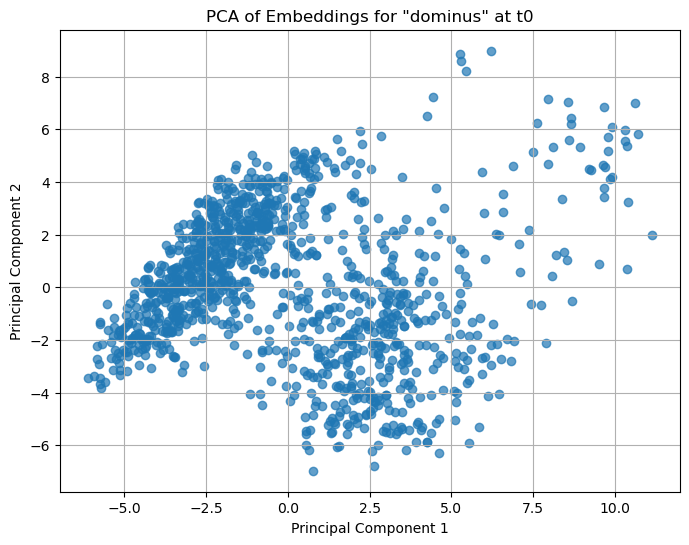

In [55]:
# Plot the reduced embeddings for word 1, t0
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings_t0_word1[:, 0], reduced_embeddings_t0_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Embeddings for "{word1}" at t0')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Save the plot to a file
output_path = os.path.join(dir_in, "output", "PCA")
os.makedirs(output_path, exist_ok=True)
plot_filename_t0 = os.path.join(output_path, f"pca_embeddings_{word1}_t0.png")
plt.savefig(plot_filename_t0, dpi=300, bbox_inches='tight')

plt.show()

Plot for t1:

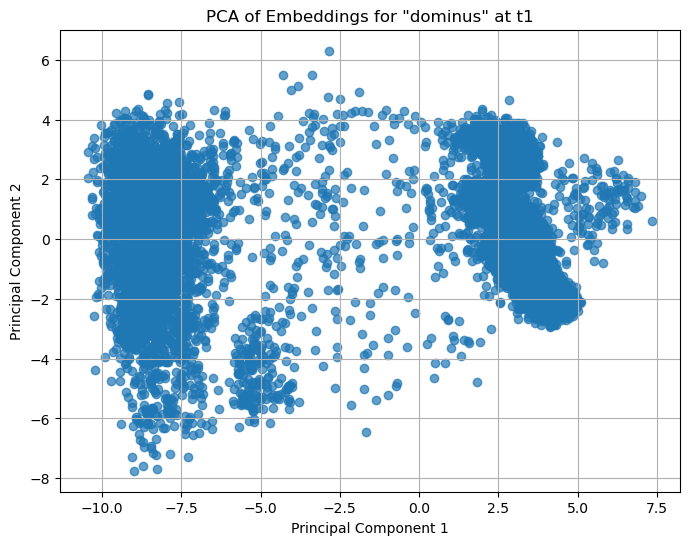

In [56]:
# Plot the reduced embeddings for word 1, t1
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings_t1_word1[:, 0], reduced_embeddings_t1_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Embeddings for "{word1}" at t1')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Save the plot to a file
plot_filename_t1 = os.path.join(output_path, f"pca_embeddings_{word1}_t1.png")
plt.savefig(plot_filename_t1, dpi=300, bbox_inches='tight')

plt.show()

Combine the plots:

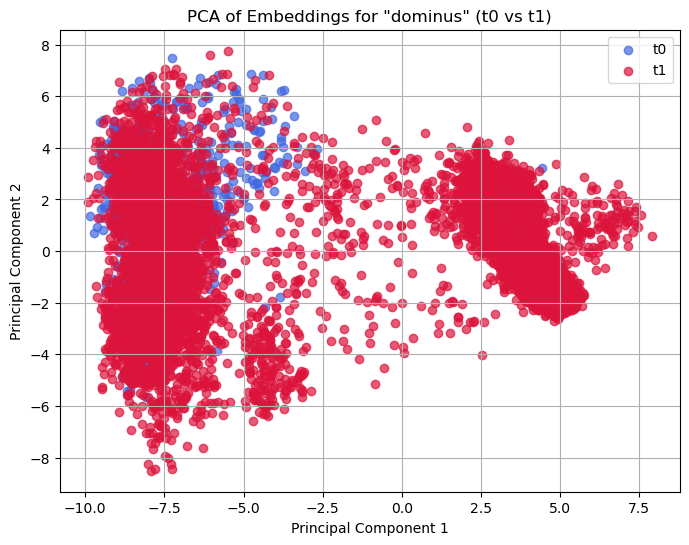

In [57]:
# Combine embeddings from t0 and t1
combined_embeddings = np.vstack([embeddings_array_t0_word1, embeddings_array_t1_word1])

# Fit PCA on the combined data
pca = PCA(n_components=100)
combined_reduced = pca.fit_transform(combined_embeddings)

# Split back into t0 and t1
reduced_t0 = combined_reduced[:len(embeddings_array_t0_word1)]
reduced_t1 = combined_reduced[len(embeddings_array_t0_word1):]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced_t0[:, 0], reduced_t0[:, 1], alpha=0.7, label='t0', color='royalblue')
plt.scatter(reduced_t1[:, 0], reduced_t1[:, 1], alpha=0.7, label='t1', color='crimson')
plt.title(f'PCA of Embeddings for "{word1}" (t0 vs t1)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)

# Save the plot to a file
plot_filename_t0t1 = os.path.join(output_path, f"pca_embeddings_{word1}_t0t1.png")
plt.savefig(plot_filename_t0t1, dpi=300, bbox_inches='tight')

plt.show()

Let's check whether the dimensionality reduction is making us lose too much in terms of representation:

In [58]:
# Calculate explained variance for t0
explained_variance_t0 = pca_t0.explained_variance_ratio_
print(f"Explained Variance for t0: {explained_variance_t0}")
print(f"Total Explained Variance for t0: {sum(explained_variance_t0):.2f}")

# Calculate explained variance for t1
explained_variance_t1 = pca_t1.explained_variance_ratio_
print(f"Explained Variance for t1: {explained_variance_t1}")
print(f"Total Explained Variance for t1: {sum(explained_variance_t1):.2f}")

Explained Variance for t0: [0.07609855 0.04968907 0.03563685 0.03489783 0.03187596 0.0283449
 0.02617579 0.01926936 0.01638059 0.01509179 0.0143347  0.0116426
 0.0110848  0.01084062 0.01056415 0.0099062  0.00922093 0.00899734
 0.00877001 0.00864985 0.00825416 0.00807479 0.00771302 0.00750387
 0.00738382 0.00710221 0.00687484 0.00673344 0.00653621 0.00634295
 0.00609707 0.00580842 0.0056835  0.00553204 0.00542329 0.00538254
 0.0051653  0.0049818  0.00487854 0.00478527 0.00466597 0.00456684
 0.0045337  0.00446832 0.00432912 0.00428708 0.00417115 0.00409682
 0.00404841 0.00392358 0.00386172 0.00377228 0.00372024 0.00361491
 0.00356093 0.00353386 0.00347785 0.0034156  0.00331433 0.00327206
 0.00323701 0.00320226 0.00315783 0.00313008 0.0031043  0.00298183
 0.00294434 0.00290641 0.00287293 0.00284761 0.00280462 0.00277032
 0.00272176 0.00269787 0.00269295 0.00266608 0.00259069 0.00257729
 0.00251913 0.00251428 0.00244568 0.00241208 0.00237101 0.00235667
 0.00233575 0.00232684 0.00225063 0.0

#### PCA-plot embeddings for a given word at t1 with subcorpus highlights

Plot saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/PCA/pca_embeddings_uirtus_t1_ridge-f1.png


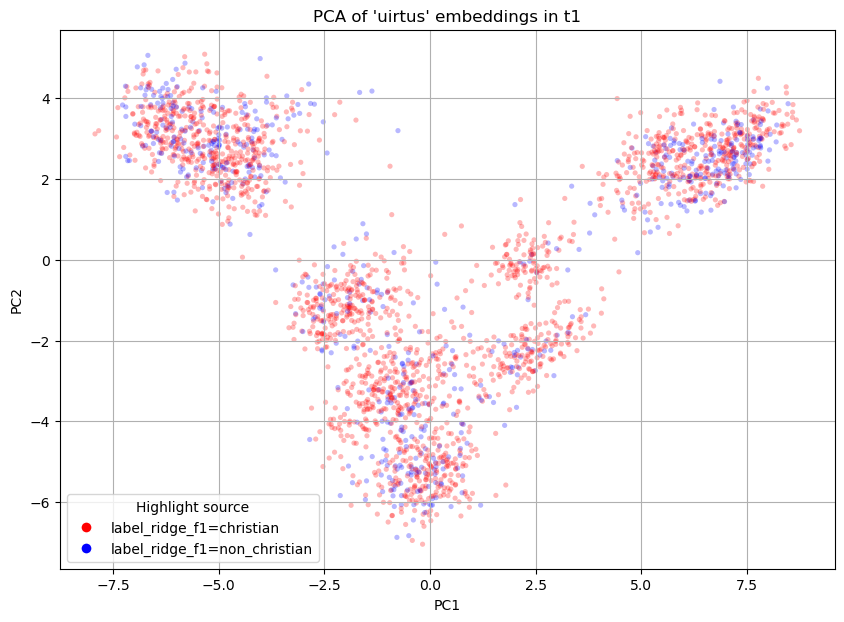

In [76]:
plot_token_embeddings_with_highlight_pca(
    berts_t1,
    target_token="uirtus",
    n_components=100,
    match_on="lemma",
    ridge_label="f1",   # or "f1"
    positive_label="christian"
)

#### t-SNE-plot embeddings for a given word at t1 with subcorpus highlights

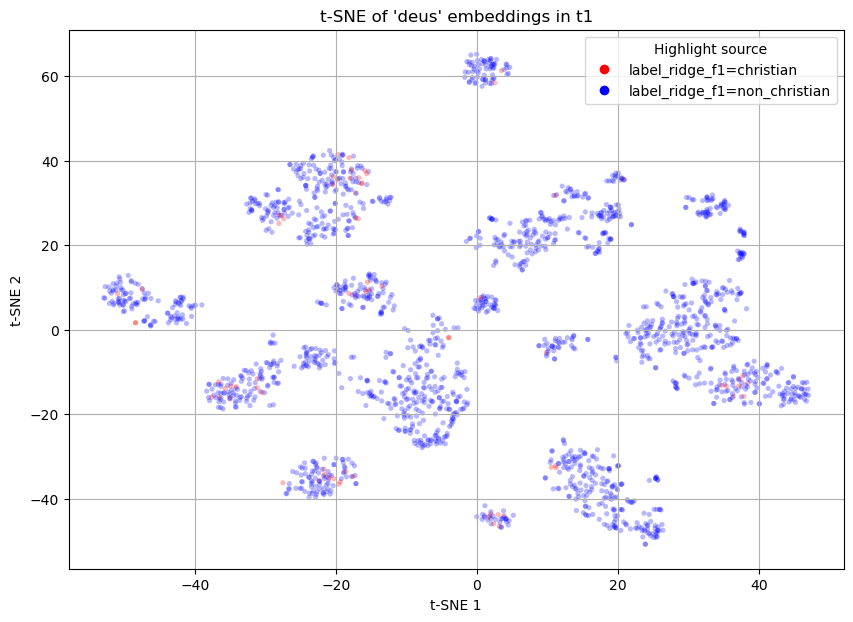

In [80]:
plot_token_embeddings_with_highlight_tsne(
    berts_t0,
    target_token="deus",
    match_on="lemma",
    ridge_label="f1",          # or "f1"
    positive_label="christian",
    max_points=2000,
    random_state=42,
    perplexity=30,
    pca_pre_reduce=50,             # <-- PCA first to 50 dims, then t-SNE
    save=False
)

In [83]:
def report_tsne_trustworthiness(X_high, X_low, neighbors=(5, 10, 15, 30), title="t-SNE trustworthiness"):
    """
    X_high: high-dimensional representation used as reference (e.g., X_pca or original embeddings)
    X_low:  low-dimensional embedding (e.g., X_tsne)
    """
    X_high = np.asarray(X_high)
    X_low = np.asarray(X_low)

    if X_high.shape[0] != X_low.shape[0]:
        raise ValueError(f"Row mismatch: X_high has {X_high.shape[0]}, X_low has {X_low.shape[0]}")

    n_samples = X_high.shape[0]
    max_valid_k = max(1, (n_samples - 1) // 2)

    results = {}
    print(title)
    print("-" * len(title))

    for k in neighbors:
        k = int(k)
        if k < 1:
            continue
        k_eff = min(k, max_valid_k)
        score = trustworthiness(X_high, X_low, n_neighbors=k_eff)
        results[k_eff] = float(score)
        print(f"k={k_eff:>2} -> {score:.4f}")

    return results

In [84]:
tw_scores = report_tsne_trustworthiness(X_pca, X_tsne, neighbors=(5, 10, 20, 30))

NameError: name 'X_pca' is not defined

#### t-SNE after PCA:

In [60]:
word1 = 'dominus'
embeddings_t0_word1 = selected_word_embeddings_t0[word1]
embeddings_t1_word1 = selected_word_embeddings_t1[word1]

# Convert the list of embeddings to a numpy array
embeddings_array_t0_word1 = np.array(embeddings_t0_word1)
embeddings_array_t1_word1 = np.array(embeddings_t1_word1)

In [59]:
X_pca, X_tsne = visualize_embeddings_pca_tsne(
    embeddings=embeddings_array_t0_word1,
    title=f"t-SNE of '{word}' embeddings in t0",
    save_path=os.path.join(dir_out, "TSNE"),
    word="deus",
    timepoint="t0",
    finetuned=False
)
score = trustworthiness(X_pca, X_tsne, n_neighbors=5)
print(f"Trustworthiness: {score:.3f}")

NameError: name 'visualize_embeddings_pca_tsne' is not defined

In [ ]:
X_pca, X_tsne = visualize_embeddings_pca_tsne(
    embeddings=embeddings_array_t1_word1,
    title=f"t-SNE of '{word}' embeddings in t1",
    save_path=os.path.join(dir_out, "TSNE"),
    word="deus",
    timepoint="t1",
    finetuned=False
)
score = trustworthiness(X_pca, X_tsne, n_neighbors=5)
print(f"Trustworthiness: {score:.3f}")

#### Similarity for clustered embeddings

Jasper Shannon Diversgence (JSD) – and clustering with affinity propagation

In [81]:
def ap_jsd(embeddings1, embeddings2):
  ap = AffinityPropagation(affinity='precomputed',
                         damping=0.9,
                         max_iter=200,
                         convergence_iter=15,
                         copy=True,
                         preference=None,
                         random_state=42)

  # clustering embeddings as a whole
  embeddings = np.concatenate([embeddings1, embeddings2], axis=0)

  # compute similarities
  sim = cosine_similarity(embeddings)

  # run clustering
  ap.fit(sim)

  # labels
  L = ap.labels_
  L1, L2 = L[:embeddings1.shape[0]], L[embeddings1.shape[0]:]
  labels = np.unique(np.concatenate([L1, L2]))

  # time-specific distributions
  c1 = Counter(L1)
  c2 = Counter(L2)
  L1_dist = np.array([c1[l] for l in labels])
  L2_dist = np.array([c2[l] for l in labels])
  L1_dist = L1_dist / L1_dist.sum()
  L2_dist = L2_dist / L2_dist.sum()

  return jensenshannon(L1_dist, L2_dist)

Single word (but some words crash)

Might need to set a limit for number of token embeddings to avoid crashing?

In [82]:
ap_jsd(np.array(selected_word_embeddings_t0["gloria"]), np.array(selected_word_embeddings_t1["gloria"]))

np.float64(0.5677200366691212)

Whole set (*but crashes*)

In [ ]:
# jsd_scores = {}
# for word in set(selected_word_embeddings_t0.keys()) & set(selected_word_embeddings_t1.keys()):
#     emb0 = np.array(selected_word_embeddings_t0[word])
#     emb1 = np.array(selected_word_embeddings_t1[word])
#     if len(emb0) > 0 and len(emb1) > 0:
#         jsd_scores[word] = ap_jsd(emb0, emb1)

# # Print sorted results
# for word, score in sorted(jsd_scores.items(), key=lambda x: x[1], reverse=True):
#     print(f"{word}: JSD = {score:.4f}")

Try also: Entropy Difference (ED), WiDiD, APD (slighly modified?)

## Fine-tuned LatinBERT

### Load embeddings

Load fine tuned embeddings for all subcorpora:

In [89]:
berts_finetuned_t0 = load_embeddings_h5("berts_finetuned_pre_180.h5", dir_emb_finetuned, batch_size=1000)

Loading embeddings from /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/embeddings_finetuned/berts_finetuned_pre_180.h5 in batches...


In [90]:
berts_finetuned_t1 = load_embeddings_h5("berts_finetuned_post_180.h5", dir_emb_finetuned, batch_size=1000)

Loading embeddings from /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/embeddings_finetuned/berts_finetuned_post_180.h5 in batches...


### Average embeddings per lemma and use similarity measurments on averages

#### Averaging operation

In [19]:
rebuild = True

Do that for all subcorpora:

In [94]:
average_embeddings_t0_finetuned, most_frequent_words_t0_finetuned = average_embeddings_by_lemma(berts_finetuned_t0, dir_avg_emb_finetuned, "average_embeddings_t0_finetuned", rebuild)

Average embeddings saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/avg_emb_finetuned/average_embeddings_t0_finetuned.h5
Word: magnus
Count: 11569
Top surface forms: [('magna', 1684), ('magno', 1129), ('maior', 816), ('magnum', 639), ('maxima', 553)]
Embedding: [-4.14637761e-04 -3.54376283e-02  5.21959966e-02 -2.47298566e-02
  1.70175782e-02 -2.77436390e-02 -1.73645866e-02  8.97463440e-03
 -4.70248477e-03  6.57085750e-04  1.18403439e-02  1.63961347e-02
 -2.61677191e-02 -2.89892105e-02  1.63273826e-02  9.12021191e-03
 -1.64686413e-02  4.72386151e-03 -9.20422691e-03  1.76376021e-02
 -7.05760617e-03 -5.49493935e-02 -6.48234317e-02  1.79826857e-02
 -4.95939884e-03 -1.13300954e-02  3.52402411e-04  2.67273614e-02
  6.51645885e-02  2.99125857e-04 -1.37150278e-02  1.36298799e-03
 -4.85874622e-02 -4.57852838e-02  1.06672517e-02  5.13722465e-03
  1.67640122e-02  1.77453738e-03  2.12676108e-02  3.15087954e-02
  1.17774617e-02 -1.0603228

In [95]:
average_embeddings_t1_finetuned, most_frequent_words_t1_finetuned = average_embeddings_by_lemma(berts_finetuned_t1, dir_avg_emb_finetuned, "average_embeddings_t1_finetuned", rebuild)

Average embeddings saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/avg_emb_finetuned/average_embeddings_t1_finetuned.h5
Word: deus
Count: 15552
Top surface forms: [('Deus', 3016), ('Dei', 2792), ('deus', 1510), ('dei', 1406), ('Deo', 1392)]
Embedding: [ 8.62937887e-03  1.53490230e-02 -2.89653686e-02  2.24820703e-02
 -4.19785274e-02 -2.40949838e-02 -5.07763685e-02 -6.87286172e-02
 -2.76054263e-02  2.38349123e-02  4.22716830e-02  2.68911803e-05
 -5.46838087e-02  1.67915344e-02 -5.66317535e-03  4.65479857e-02
  7.26168840e-03  1.36927028e-02 -5.55478791e-02 -1.29350858e-02
 -3.38822969e-03 -3.64383789e-02 -7.15063885e-02  5.15943772e-02
  1.16193198e-02 -1.13295151e-02 -3.04845069e-02 -7.55836445e-03
  7.13449886e-02  2.73339216e-02 -3.85252197e-02 -1.45483257e-02
 -2.75483442e-02 -3.58524273e-02  1.63395564e-02  3.14021777e-02
 -1.91863180e-03 -2.19051300e-02  3.42224714e-02  2.90261054e-02
  3.03938435e-02 -3.16077549e-02  1.

Sanity check: print the most common 500 words in t0 and t1

In [96]:
# Dictionary to store embeddings for each word type
word_embeddings = defaultdict(list)
word_counter = Counter()
    
# Collect all embeddings for each word type and count word frequencies
for record in berts_finetuned_t0:
    for token in record["tokens"]:
        lemma = token["lemma"]
        embedding = token["embedding"]
        word_embeddings[lemma].append(embedding)
        word_counter[lemma] += 1

# Get the 500 most frequent words
most_frequent_words_t0_finetuned = [word for word, _ in word_counter.most_common(500)]

# Print the embeddings for the ten most frequent words
for word in most_frequent_words_t0_finetuned:
    print(f"Word: {word}")

Word: magnus
Word: animus
Word: pater
Word: uolo
Word: pars
Word: homo
Word: unus
Word: locus
Word: romanus
Word: bellum
Word: dies
Word: ago
Word: primus
Word: uenio
Word: tempus
Word: urbs
Word: hostis
Word: deus
Word: bonus
Word: uir
Word: consul
Word: populus
Word: uis
Word: corpus
Word: modus
Word: manus
Word: publicus
Word: rex
Word: genus
Word: nomen
Word: totus
Word: arma
Word: iubeo
Word: terra
Word: mitto
Word: miles
Word: peto
Word: senatus
Word: uerbum
Word: credo
Word: duo
Word: capio
Word: quaero
Word: domus
Word: annus
Word: puto
Word: uita
Word: uirtus
Word: lex
Word: exercitus
Word: sequor
Word: audio
Word: scio
Word: os
Word: accipio
Word: castra
Word: teneo
Word: pono
Word: opus
Word: debeo
Word: ratio
Word: natura
Word: duco
Word: ius
Word: caesar
Word: nouus
Word: fortuna
Word: gero
Word: mille
Word: mors
Word: uinco
Word: relinquo
Word: paruus
Word: medius
Word: dux
Word: ager
Word: consilium
Word: nox
Word: refero
Word: caput
Word: fides
Word: uox
Word: signum
Wo

In [97]:
# Dictionary to store embeddings for each word type
word_embeddings = defaultdict(list)
word_counter = Counter()
    
# Collect all embeddings for each word type and count word frequencies
for record in berts_finetuned_t1:
    for token in record["tokens"]:
        lemma = token["lemma"]
        embedding = token["embedding"]
        word_embeddings[lemma].append(embedding)
        word_counter[lemma] += 1

# Get the 500 most frequent words
most_frequent_words_t1_finetuned = [word for word, _ in word_counter.most_common(500)]

# Print the embeddings for the ten most frequent words
for word in most_frequent_words_t1_finetuned:
    print(f"Word: {word}")

Word: deus
Word: dominus
Word: dies
Word: filius
Word: cio
Word: rex
Word: homo
Word: pater
Word: magnus
Word: terra
Word: unus
Word: uenio
Word: locus
Word: tempus
Word: nomen
Word: pars
Word: uolo
Word: conss
Word: uir
Word: populus
Word: imperator
Word: manus
Word: uerbum
Word: kalendae
Word: corpus
Word: lex
Word: domus
Word: christus
Word: annus
Word: primus
Word: sanctus
Word: credo
Word: uita
Word: debeo
Word: totus
Word: imperatores
Word: mors
Word: ago
Word: ius
Word: mitto
Word: audio
Word: bonus
Word: accipio
Word: fides
Word: pono
Word: loquor
Word: frater
Word: duo
Word: os
Word: urbs
Word: liber
Word: solus
Word: cunctus
Word: caelum
Word: anima
Word: ciuitas
Word: uis
Word: bellum
Word: gens
Word: iubeo
Word: teneo
Word: mater
Word: uox
Word: genus
Word: inuenio
Word: opus
Word: scio
Word: modus
Word: animus
Word: caput
Word: uoco
Word: uirtus
Word: regnum
Word: peto
Word: quaero
Word: ratio
Word: mens
Word: aqua
Word: sequor
Word: cc
Word: cor
Word: capio
Word: spiritus

#### Cosine similarity and PRT

Between t0 and t1:

In [98]:
# Compute cosine similarity for each token that appears in both t0 and t1
cosine_similarities_t0t1_finetuned = {}
for token in average_embeddings_t0_finetuned:
    if token in average_embeddings_t1_finetuned:
        embedding_t0 = average_embeddings_t0_finetuned[token].reshape(1, -1)
        embedding_t1 = average_embeddings_t1_finetuned[token].reshape(1, -1)
        similarity = cosine_similarity(embedding_t0, embedding_t1)[0][0]
        cosine_similarities_t0t1_finetuned[token] = similarity

# Sort by similarity value (descending)
sorted_similarities = sorted(cosine_similarities_t0t1_finetuned.items(), key=lambda x: x[1], reverse=True)

# Print the sorted cosine similarities
for token, similarity in sorted_similarities:
    print(f"Token: {token}, Cosine Similarity: {similarity}")  

Token: graecia, Cosine Similarity: 0.9979702645306148
Token: phoebus, Cosine Similarity: 0.9978798973970646
Token: athenae, Cosine Similarity: 0.9973102901950048
Token: cicero, Cosine Similarity: 0.997266163844817
Token: metellus, Cosine Similarity: 0.9969857988418502
Token: lacedaemonii, Cosine Similarity: 0.9968921277028826
Token: athenienses, Cosine Similarity: 0.9968509750894123
Token: asia, Cosine Similarity: 0.9968337905437599
Token: parthi, Cosine Similarity: 0.9968108366463653
Token: caesar, Cosine Similarity: 0.9966698268837229
Token: macedonia, Cosine Similarity: 0.9964578283382372
Token: hector, Cosine Similarity: 0.9964514228299353
Token: italia, Cosine Similarity: 0.9964484833796735
Token: phryges, Cosine Similarity: 0.9963560578480293
Token: capitolium, Cosine Similarity: 0.9963534502172101
Token: rhenus, Cosine Similarity: 0.9963348509216203
Token: pompeius, Cosine Similarity: 0.9962545372190518
Token: pythagoras, Cosine Similarity: 0.9962477019946766
Token: lacedaemoniu

In [100]:
# Write the cosine similarities to a CSV file
cosine_sim_csv = os.path.join(dir_out, "csv", "cosine_similarities_t0t1_finetuned.csv")

with open(cosine_sim_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Token", "Cosine Similarity"])  # Write the header
    for token, similarity in cosine_similarities_t0t1_finetuned.items():
        writer.writerow([token, similarity])

print(f"Cosine similarities saved to {cosine_sim_csv}")

Cosine similarities saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/csv/cosine_similarities_t0t1_finetuned.csv


Note: there is also **PRT**, a.k.a. inverted cosine similarity over word prototypes – meaning over embeddings averaged by token or lemma (across the different corpora). The only difference is that, as per the definition, it's 1 / cosine similarity. There is some evidence that it yields slighly better results than cosine similarity by itself.

Calculate it for average embeddings between (1) t0 and t1 and (2) christian and non-christian subcorpora:

In [101]:
# Compute PRT values from cosine similarities
prt_t0t1_finetuned = {}
for token, similarity in cosine_similarities_t0t1_finetuned.items():
    prt_t0t1_finetuned[token] = 1 / similarity if similarity != 0 else float('inf')

# Sort by PRT value (descending: higher means more change)
sorted_prt = sorted(prt_t0t1_finetuned.items(), key=lambda x: x[1], reverse=False)

# Print the sorted PRT values
for token, prt_value in sorted_prt:
    print(f"Token: {token}, PRT: {prt_value}")

Token: graecia, PRT: 1.0020338636746255
Token: phoebus, PRT: 1.0021246069877403
Token: athenae, PRT: 1.00269696385512
Token: cicero, PRT: 1.002741330503627
Token: metellus, PRT: 1.003023314034815
Token: lacedaemonii, PRT: 1.0031175612794523
Token: athenienses, PRT: 1.003158972593978
Token: asia, PRT: 1.0031762661802557
Token: parthi, PRT: 1.0031993666565306
Token: caesar, PRT: 1.003341300224458
Token: macedonia, PRT: 1.0035547632433879
Token: hector, PRT: 1.0035612144142327
Token: italia, PRT: 1.0035641748465316
Token: phryges, PRT: 1.0036572690287457
Token: capitolium, PRT: 1.003659895774933
Token: rhenus, PRT: 1.0036786318123765
Token: pompeius, PRT: 1.0037595440131226
Token: pythagoras, PRT: 1.0037664307760115
Token: lacedaemonius, PRT: 1.0037776940561094
Token: aurora, PRT: 1.003779853858454
Token: priamus, PRT: 1.0038736182081116
Token: macedones, PRT: 1.003877394133875
Token: nilus, PRT: 1.0038796369002905
Token: pyrrhus, PRT: 1.0039968763751497
Token: musa, PRT: 1.00404605104651

In [103]:
# Write the PRT values to a CSV file
prt_csv = os.path.join(dir_out, "csv", "prt_t0t1_finetuned.csv")

with open(prt_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Token", "PRT"])  # Write the header
    for token, similarity in prt_t0t1_finetuned.items():
        writer.writerow([token, similarity])

print(f"PRT values saved to {prt_csv}")

PRT values saved to /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/csv/prt_t0t1_finetuned.csv


#### A function showing us neighbors (as you'd try and find for static embeddings)

Look at some "neighbours" for the various subcorpora:

In [ ]:
neighbors = find_neighbors("deus", average_embeddings_t0_finetuned, top_k=15)
print(neighbors)

[('dea', 0.9237722), ('iuppiter', 0.9167839), ('numen', 0.8698712), ('deo', 0.8553757), ('dis', 0.854882), ('apollo', 0.85366845), ('diuus', 0.84661275), ('semideus', 0.83801377), ('divinus', 0.83331114), ('mars', 0.8294827)]


In [ ]:
neighbors = find_neighbors("deus", average_embeddings_t1_finetuned, top_k=15)
print(neighbors)

[('dea', 0.8849883), ('iuppiter', 0.881944), ('dominus', 0.85319966), ('numen', 0.84454685), ('christus', 0.8375001), ('divinus', 0.83123505), ('semideus', 0.83084625), ('chaldeus', 0.82988507), ('caesar', 0.82223296), ('diuus', 0.81806785), ('tyrannus', 0.81565034), ('diuinitas', 0.81534266), ('apollo', 0.81527495), ('religio', 0.8145581), ('iesus', 0.8136206)]


In [ ]:
neighbors = find_neighbors("oratio", average_embeddings_t0_finetuned, top_k=15)
print(neighbors)

[('sermo', 0.88315743), ('dictio', 0.88126135), ('disputatio', 0.8783839), ('orator', 0.8759661), ('lectio', 0.87451994), ('locutio', 0.87179434), ('hymnus', 0.86859286), ('accusatio', 0.86759675), ('expositio', 0.86595523), ('narratio', 0.8654699), ('legatio', 0.86133194), ('eloquentia', 0.8600211), ('confessio', 0.85731345), ('oblatio', 0.8555622), ('praedicatio', 0.85321987)]


In [ ]:
neighbors = find_neighbors("oratio", average_embeddings_t1_finetuned, top_k=15)
print(neighbors)

[('sermo', 0.9077481), ('accusatio', 0.88871616), ('eloquentia', 0.8870548), ('orator', 0.8858463), ('disputatio', 0.88404125), ('actio', 0.8831697), ('locutio', 0.8750082), ('dictio', 0.8707267), ('uerbum', 0.8663684), ('compositio', 0.8657644), ('expositio', 0.8622035), ('auditor', 0.8597053), ('narratio', 0.85810435), ('historia', 0.85761213), ('interrogatio', 0.8565335)]


Try and plot target averaged embeddings with their neighbours:

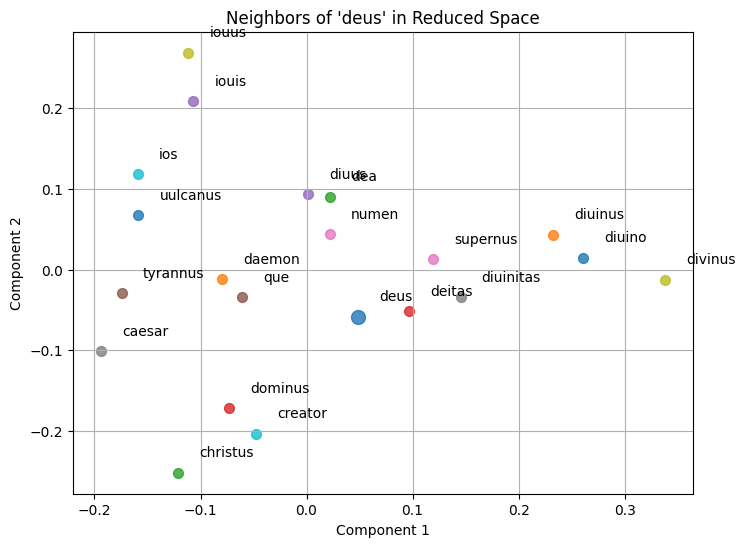

In [ ]:
# Example: Plot neighbors of "deus"
neighbors = find_neighbors("deus", average_embeddings_t1_finetuned, top_k=20)
plot_neighbors("deus", neighbors, average_embeddings_t1_finetuned, output_dir=os.path.join(dir_out, "PCA")) #if you don't want to save the plot, delete the output_dir argument

In [ ]:
# Change list of words and filename as needed
save_neighbors(
    word_list=["scriptura", "lectio", "deus", "dominus", "creator", "factor", "deductor", "oratio", "lex", "altarium", "tabernaculum", "memoria", "recessus", "frater", "soror", "canticum", "uirtus", "gratia", "gloria", "panis", "anima","sanctus", "beatus", "peccator", "communio", "communico"],
    average_embeddings=average_embeddings_t1_finetuned,
    top_k=10,
    output_dir=os.path.join(dir_out, "csv"),
    output_filename="neighbors_t1_finetuned_no-lem.csv"
)

Neighbors saved to /Users/valentinalunardi/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/csv/neighbors_t1_finetuned_no-lem.csv


: 

#### A different method for measuring: APD, or average pairwise cosine distance

Average Pairwise Distance (APD) measures semantic change by computing the average distance (cosine or euclidean, but cosine here) between all possible pairs of contextualized embeddings of a word across two time slices or corpora. Thus, APD does not require any aggregation or clustering. It reflects the variance in word meaning by directly comparing token-level embeddings.

In [ ]:
# Define terms of interest
# christian_terms = ["scriptura", "lectio", "deus", "dominus", "creator", "factor", "deductor", "oratio", "lex", "altarium", "tabernaculum", "memoria", "recessus", "frater", "soror", "canticum", "uirtus", "gratia", "gloria", "panis", "anima","sanctus", "beatus", "peccator", "communio", "communico"]
changed_lemmas = [
    "beatus", "credo", "fidelis", "pontifex", "potestas", "sacramentum", "sanctus", "scriptura", "uirtus"
]

# Extract embeddings for the selected terms from both time points
selected_word_embeddings_t0 = extract_selected_embeddings(berts_finetuned_t0, changed_lemmas)
selected_word_embeddings_t1 = extract_selected_embeddings(berts_finetuned_t1, changed_lemmas)

# Compute APD for the selected terms
apd_results = compute_apd_selected(selected_word_embeddings_t0, selected_word_embeddings_t1)

# Sort and print results
if not apd_results:
    print("No APD scores computed.")
else:
    for lemma, score in sorted(apd_results.items(), key=lambda x: x[1], reverse=True):
        print(f"{lemma}: APD = {score:.4f}")

imperator: APD = 0.6192
sanctus: APD = 0.5847
credo: APD = 0.5647
fidelis: APD = 0.5557
beatus: APD = 0.5401
scriptura: APD = 0.5331
dolus: APD = 0.5222
sacramentum: APD = 0.5150
pontifex: APD = 0.5094
humanitas: APD = 0.5026
potestas: APD = 0.5007
itero: APD = 0.4947
dux: APD = 0.4865
consul: APD = 0.4823
uirtus: APD = 0.4714
cohors: APD = 0.4604
ciuitas: APD = 0.4139


In [127]:
apd_csv = os.path.join(dir_out, "csv", "apd_results_christian_terms_finetuned_no-lem.csv")
with open(apd_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Lemma", "APD"])
    for lemma, score in sorted(apd_results.items(), key=lambda x: x[1], reverse=True):
        writer.writerow([lemma, score])
print(f"APD results saved to {apd_csv}")

APD results saved to /Users/valentinalunardi/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/csv/apd_results_christian_terms_finetuned_no-lem.csv


In [108]:
# Define terms of interest
# control_terms = ["panis", "tabula", "canis", "aqua", "navis", "nox", "dies", "puer", "femina"]

stable_lemmas = [
    "acerbus", "adsumo", "ancilla", "consilium", "dubius", "honor",
    "hostis", "ius", "liceo", "necessarius", "nepos", "nobilitas",
    "oportet", "poena", "regnum", "salus", "sapientia", "senatus",
    "sensus", "simplex", "templum", "titulus", "uoluntas"
]

# Extract embeddings for the selected terms from both time points
selected_word_embeddings_t0 = extract_selected_embeddings(berts_finetuned_t0, stable_lemmas)
selected_word_embeddings_t1 = extract_selected_embeddings(berts_finetuned_t1, stable_lemmas)
# Compute APD for the selected terms
apd_results = compute_apd_selected(selected_word_embeddings_t0, selected_word_embeddings_t1)

# Sort and print results
if not apd_results:
    print("No APD scores computed.")
else:
    for lemma, score in sorted(apd_results.items(), key=lambda x: x[1], reverse=True):
        print(f"{lemma}: APD = {score:.4f}")

simplex: APD = 0.5463
dubius: APD = 0.5451
nepos: APD = 0.5277
titulus: APD = 0.5259
nobilitas: APD = 0.5256
honor: APD = 0.5147
consilium: APD = 0.4949
ius: APD = 0.4915
sensus: APD = 0.4893
salus: APD = 0.4847
poena: APD = 0.4828
ancilla: APD = 0.4827
necessarius: APD = 0.4766
senatus: APD = 0.4766
acerbus: APD = 0.4735
templum: APD = 0.4713
sapientia: APD = 0.4709
regnum: APD = 0.4667
adsumo: APD = 0.4537
hostis: APD = 0.4509
oportet: APD = 0.4420
liceo: APD = 0.4388
uoluntas: APD = 0.4036


In [126]:
apd_csv = os.path.join(dir_out, "csv", "apd_results_control_terms_finetuned_no-lem.csv")
with open(apd_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Lemma", "APD"])
    for lemma, score in sorted(apd_results.items(), key=lambda x: x[1], reverse=True):
        writer.writerow([lemma, score])
print(f"APD results saved to {apd_csv}")

APD results saved to /Users/valentinalunardi/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/csv/apd_results_control_terms_finetuned_no-lem.csv


In [ ]:
# APD for all shared lemmas excluding the top N most frequent (function words / noise)
# Fine-tuned model

top_n_exclude = 100  # adjust as needed

# Count lemma frequencies across both time points
freq_t0_ft = Counter()
for record in berts_finetuned_t0:
    for token in record["tokens"]:
        freq_t0_ft[token["lemma"]] += 1

freq_t1_ft = Counter()
for record in berts_finetuned_t1:
    for token in record["tokens"]:
        freq_t1_ft[token["lemma"]] += 1

combined_freq_ft = freq_t0_ft + freq_t1_ft
stopword_lemmas_ft = {lemma for lemma, _ in combined_freq_ft.most_common(top_n_exclude)}
print(f"Excluding top {top_n_exclude} most frequent lemmas: {sorted(stopword_lemmas_ft)}")

shared_lemmas_broad_ft = (set(freq_t0_ft.keys()) & set(freq_t1_ft.keys())) - stopword_lemmas_ft
print(f"\nComputing APD for {len(shared_lemmas_broad_ft)} shared non-frequent lemmas...")

selected_t0_broad_ft = extract_selected_embeddings(berts_finetuned_t0, list(shared_lemmas_broad_ft), match_on="lemma")
selected_t1_broad_ft = extract_selected_embeddings(berts_finetuned_t1, list(shared_lemmas_broad_ft), match_on="lemma")
apd_broad_ft = compute_apd_selected(selected_t0_broad_ft, selected_t1_broad_ft)

print(f"\nTop 30 by APD (most changed):")
for lemma, score in sorted(apd_broad_ft.items(), key=lambda x: x[1], reverse=True)[:30]:
    print(f"  {lemma}: {score:.4f}")

apd_broad_ft_csv = os.path.join(dir_out, "csv", "apd_broad_finetuned.csv")
with open(apd_broad_ft_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Lemma", "APD"])
    for lemma, score in sorted(apd_broad_ft.items(), key=lambda x: x[1], reverse=True):
        writer.writerow([lemma, score])
print(f"\nBroad APD (fine-tuned) saved to {apd_broad_ft_csv}")

### Cluster embeddings for a small set of selected words (too expensive to do it across the whole corpus!)

Let's do something less computationally demanding and more focussed: extract embeddings for just a handful of target words for both t0 and t1 and test clustering methods on those, potentially after some PCA plotting.

Define small selection of words:

In [69]:
christian_terms = ["scriptura", "lectio", "deus", "dominus", "creator", "factor", "deductor", "oratio", "lex", "altarium", "tabernaculum", "memoria", "recessus", "frater", "soror", "canticum", "uirtus", "gratia", "gloria", "panis", "anima","sanctus", "beatus", "peccator", "communio", "communico"]

Extract embeddings from fine-tuned corpus for the small selection of words:

In [ ]:
selected_word_embeddings_t0_finetuned = extract_selected_embeddings(berts_finetuned_t0, christian_terms)
selected_word_embeddings_t1_finetuned = extract_selected_embeddings(berts_finetuned_t1, christian_terms)

#### PCA-plot embeddings for a given word at t0, t1, and for the whole timeframe

Pick a word:

In [82]:
word1 = 'deus'
embeddings_t0_word1 = selected_word_embeddings_t0_finetuned[word1]
embeddings_t1_word1 = selected_word_embeddings_t1_finetuned[word1]

# Convert the list of embeddings to a numpy array
embeddings_array_t0_word1 = np.array(embeddings_t0_word1)
embeddings_array_t1_word1 = np.array(embeddings_t1_word1)

Reduce dimensionality with PCA (adjust `n_components` as needed):

In [83]:
# Perform PCA to reduce the dimensionality
pca_t0 = PCA(n_components=100)
reduced_embeddings_t0_word1 = pca_t0.fit_transform(embeddings_array_t0_word1)
pca_t1 = PCA(n_components=100)
reduced_embeddings_t1_word1 = pca_t1.fit_transform(embeddings_array_t1_word1)

Plot for t0:

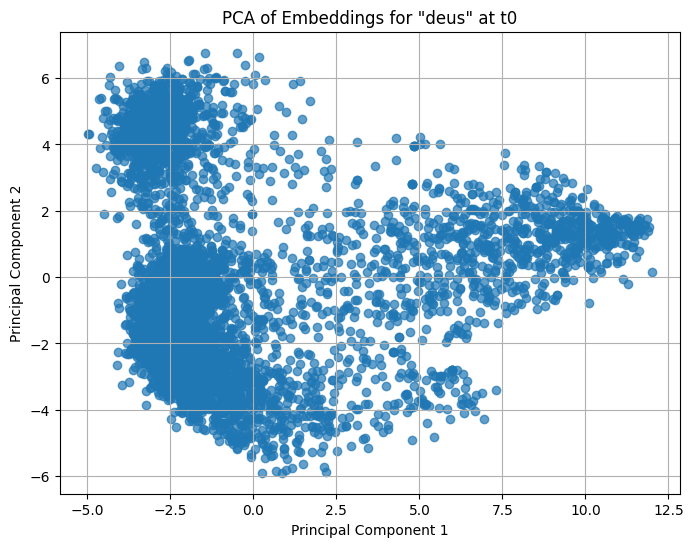

In [ ]:
# Plot the reduced embeddings for word 1, t0
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings_t0_word1[:, 0], reduced_embeddings_t0_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Embeddings for "{word1}" at t0')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Save the plot to a file
output_path = os.path.join(dir_out, "PCA")
os.makedirs(output_path, exist_ok=True)
plot_filename_t0 = os.path.join(output_path, f"pca_embeddings_{word1}_t0_finetuned.png")
plt.savefig(plot_filename_t0, dpi=300, bbox_inches='tight')
plt.show()

Plot for t1:

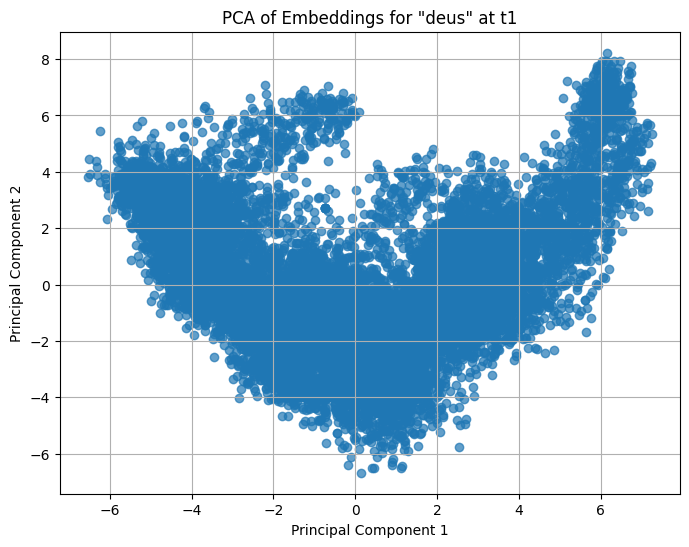

In [87]:
# Plot the reduced embeddings for word 1, t1
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings_t1_word1[:, 0], reduced_embeddings_t1_word1[:, 1], alpha=0.7)
plt.title(f'PCA of Embeddings for "{word1}" at t1')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Save the plot to a file
plot_filename_t1 = os.path.join(output_path, f"pca_embeddings_{word1}_t1_finetuned_2.png")
plt.savefig(plot_filename_t1, dpi=300, bbox_inches='tight')

plt.show()

Let's check whether the dimensionality reduction is making us lose too much in terms of representation:

In [88]:
# Calculate explained variance for t0
explained_variance_t0 = pca_t0.explained_variance_ratio_
print(f"Explained Variance for t0: {explained_variance_t0}")
print(f"Total Explained Variance for t0: {sum(explained_variance_t0):.2f}")

# Calculate explained variance for t1
explained_variance_t1 = pca_t1.explained_variance_ratio_
print(f"Explained Variance for t1: {explained_variance_t1}")
print(f"Total Explained Variance for t1: {sum(explained_variance_t1):.2f}")

Explained Variance for t0: [0.13371775 0.06816465 0.04312938 0.03625226 0.03364706 0.02716809
 0.02154899 0.01641822 0.01466018 0.0138485  0.01293803 0.01201663
 0.01032557 0.00981681 0.00939501 0.00927962 0.0087249  0.00804747
 0.00760026 0.00738771 0.00693701 0.00670568 0.00655611 0.00604161
 0.0058819  0.00568972 0.00560115 0.00533172 0.0052518  0.00503135
 0.00487415 0.00471305 0.00450442 0.00438769 0.00424117 0.00419061
 0.00408105 0.00400975 0.00389525 0.0037938  0.0036876  0.00366535
 0.00358372 0.00353981 0.00335969 0.0032514  0.00320766 0.00318519
 0.00313306 0.00307754 0.00305639 0.00295798 0.00294409 0.00291994
 0.00283865 0.00280239 0.00273889 0.00271382 0.0026621  0.00262354
 0.00260373 0.00256153 0.00247006 0.00244512 0.00242123 0.00235731
 0.00233744 0.0023178  0.00227437 0.00224383 0.00221378 0.0021975
 0.00213258 0.00209795 0.00208636 0.00206198 0.00203517 0.0020125
 0.00198519 0.0019724  0.00192762 0.00190785 0.00187015 0.00185566
 0.00183764 0.00181927 0.00180571 0.0

Combine the plots:

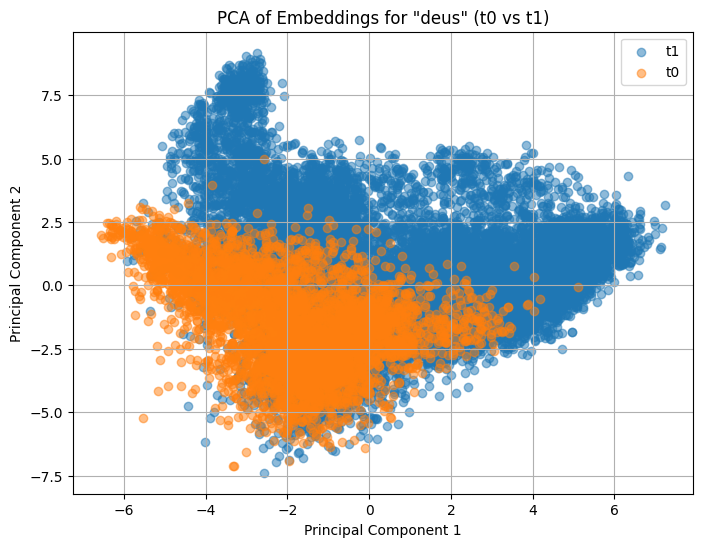

In [ ]:
# Combine embeddings from t0 and t1
combined_embeddings = np.vstack([embeddings_array_t0_word1, embeddings_array_t1_word1])

# Fit PCA on the combined data
pca = PCA(n_components=100)  # or n_components=100 if you want more dimensions
combined_reduced = pca.fit_transform(combined_embeddings)

# Split back into t0 and t1
reduced_t0 = combined_reduced[:len(embeddings_array_t0_word1)]
reduced_t1 = combined_reduced[len(embeddings_array_t0_word1):]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced_t1[:, 0], reduced_t1[:, 1], alpha=0.5, label='t1')
plt.scatter(reduced_t0[:, 0], reduced_t0[:, 1], alpha=0.5, label='t0')
plt.title(f'PCA of Embeddings for "{word1}" (t0 vs t1)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)

# Save the plot to a file
plot_filename_t0t1 = os.path.join(output_path, f"pca_embeddings_{word1}_t0t1_finetuned.png")
plt.savefig(plot_filename_t0t1, dpi=300, bbox_inches='tight')

plt.show()

#### PCA-plot embeddings for a given word at t1 with subcorpus highlights

Plot saved to /Users/valentinalunardi/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/PCA/pca_embeddings_deus_t1_christi-highlight.png


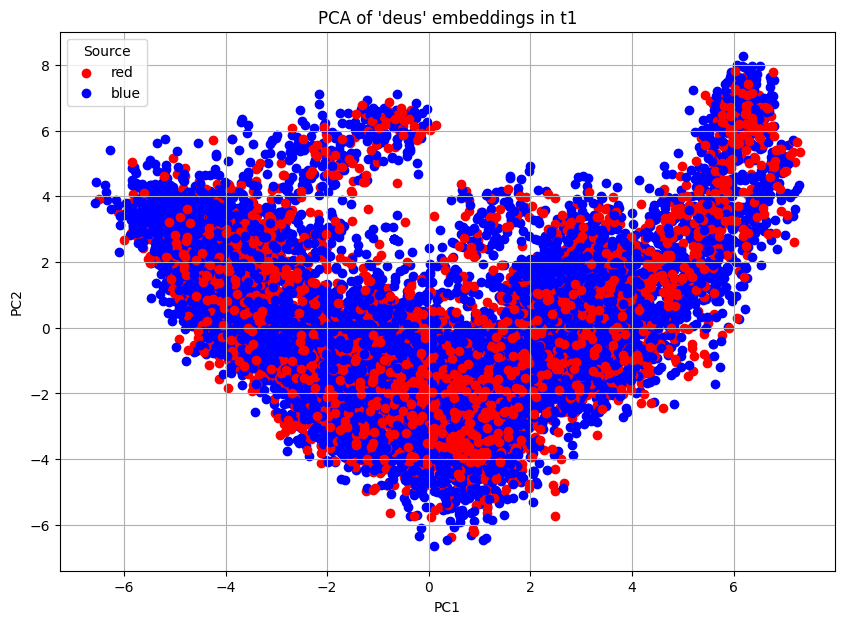

In [94]:
plot_token_embeddings_with_highlight(berts_finetuned_t1_lemmatized, time2corpus[1], corpus_christi, target_token='deus', n_components=100)

Calculate optimal number of clusters and silhouette score:

In [95]:
embeddings_t0 = selected_word_embeddings_t0_finetuned['deus']
embeddings_t1 = selected_word_embeddings_t1_finetuned['deus']
best_k_t0, best_score_t0 = optimal_num_clusters(embeddings_t0, min_k=2, max_k=10)
best_k_t1, best_score_t1 = optimal_num_clusters(embeddings_t1, min_k=2, max_k=10)
print(f"Optimal number of clusters for 'deus' at t0: {best_k_t0}, Silhouette Score: {best_score_t0:.4f}")
print(f"Optimal number of clusters for 'deus' at t1: {best_k_t1}, Silhouette Score: {best_score_t1:.4f}")

Optimal number of clusters for 'deus' at t0: 3, Silhouette Score: 0.1281
Optimal number of clusters for 'deus' at t1: 7, Silhouette Score: 0.1022


Plot saved to /Users/valentinalunardi/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/PCA/pca_embeddings_oratio_t1_christi-highlight.png


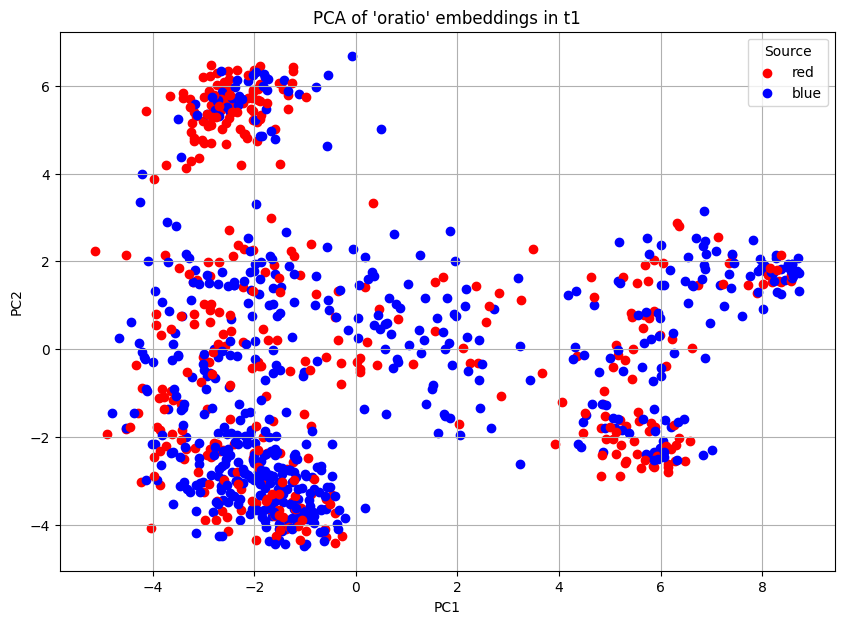

In [96]:
plot_token_embeddings_with_highlight(berts_finetuned_t1_lemmatized, time2corpus[1], corpus_christi, target_token='oratio', n_components=100)

In [97]:
embeddings_t0 = selected_word_embeddings_t0_finetuned['oratio']
embeddings_t1 = selected_word_embeddings_t1_finetuned['oratio']
best_k_t0, best_score_t0 = optimal_num_clusters(embeddings_t0, min_k=2, max_k=10)
best_k_t1, best_score_t1 = optimal_num_clusters(embeddings_t1, min_k=2, max_k=10)
print(f"Optimal number of clusters for 'oratio' at t0: {best_k_t0}, Silhouette Score: {best_score_t0:.4f}")
print(f"Optimal number of clusters for 'oratio' at t1: {best_k_t1}, Silhouette Score: {best_score_t1:.4f}")

Optimal number of clusters for 'oratio' at t0: 2, Silhouette Score: 0.1413
Optimal number of clusters for 'oratio' at t1: 6, Silhouette Score: 0.1386


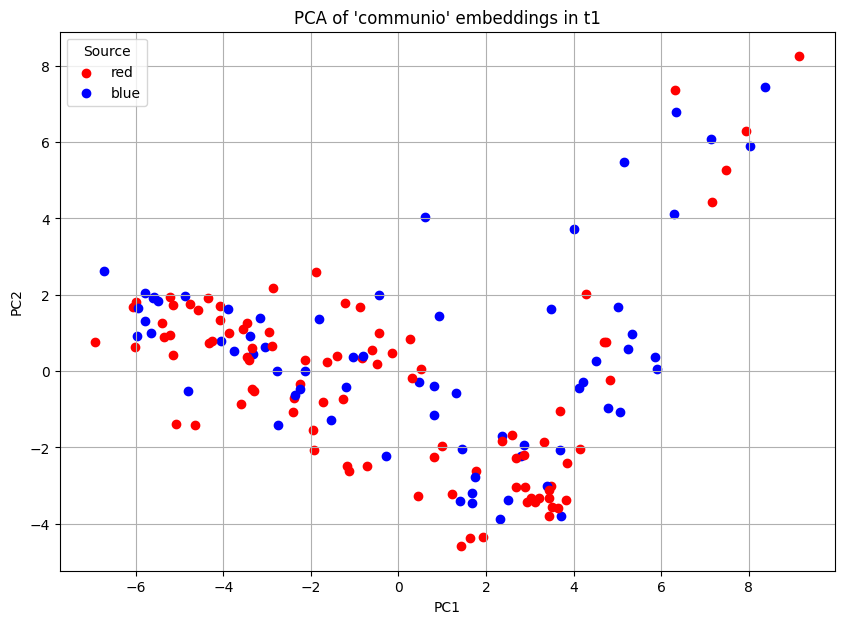

<Figure size 640x480 with 0 Axes>

In [99]:
plot_token_embeddings_with_highlight(berts_finetuned_t1, time2corpus[1], corpus_christi, target_token='communio', n_components=100)

In [82]:
embeddings_t0 = selected_word_embeddings_t0_finetuned['dominus']
embeddings_t1 = selected_word_embeddings_t1_finetuned['dominus']
best_k_t0, best_score_t0 = optimal_num_clusters(embeddings_t0, min_k=2, max_k=10)
best_k_t1, best_score_t1 = optimal_num_clusters(embeddings_t1, min_k=2, max_k=10)
print(f"Optimal number of clusters for 'dominus' at t0: {best_k_t0}, Silhouette Score: {best_score_t0:.4f}")
print(f"Optimal number of clusters for 'dominus' at t1: {best_k_t1}, Silhouette Score: {best_score_t1:.4f}")

Optimal number of clusters for 'dominus' at t0: 2, Silhouette Score: 0.0670
Optimal number of clusters for 'dominus' at t1: 2, Silhouette Score: 0.1159


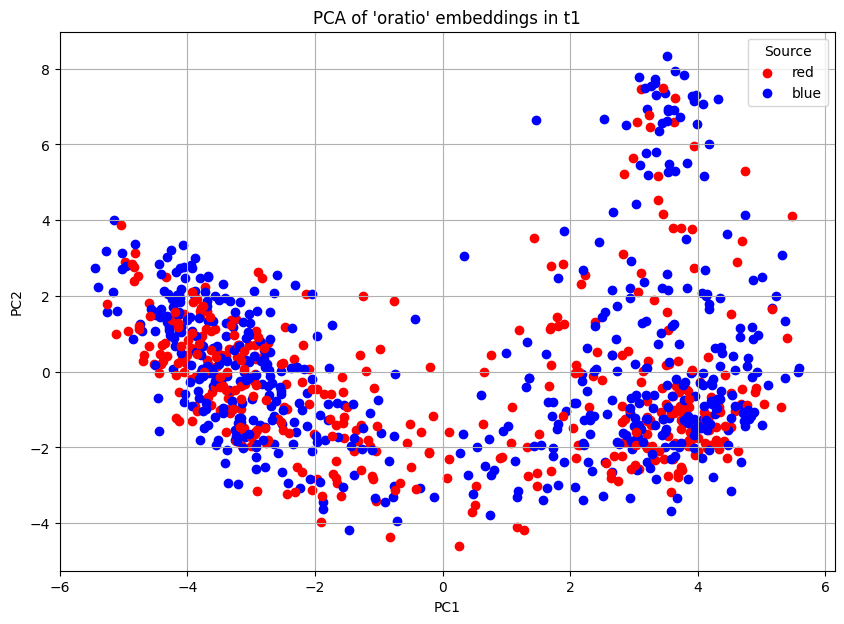

In [61]:
plot_token_embeddings_with_highlight(berts_finetuned_t1, time2corpus[1], corpus_christi, target_token='oratio', n_components=100)

In [83]:
embeddings_t0 = selected_word_embeddings_t0_finetuned['oratio']
embeddings_t1 = selected_word_embeddings_t1_finetuned['oratio']
best_k_t0, best_score_t0 = optimal_num_clusters(embeddings_t0, min_k=2, max_k=10)
best_k_t1, best_score_t1 = optimal_num_clusters(embeddings_t1, min_k=2, max_k=10)
print(f"Optimal number of clusters for 'oratio' at t0: {best_k_t0}, Silhouette Score: {best_score_t0:.4f}")
print(f"Optimal number of clusters for 'oratio' at t1: {best_k_t1}, Silhouette Score: {best_score_t1:.4f}")

Optimal number of clusters for 'oratio' at t0: 3, Silhouette Score: 0.1059
Optimal number of clusters for 'oratio' at t1: 2, Silhouette Score: 0.1331


#### t-SNE-plot embeddings for a given word at t1 with subcorpus highlights

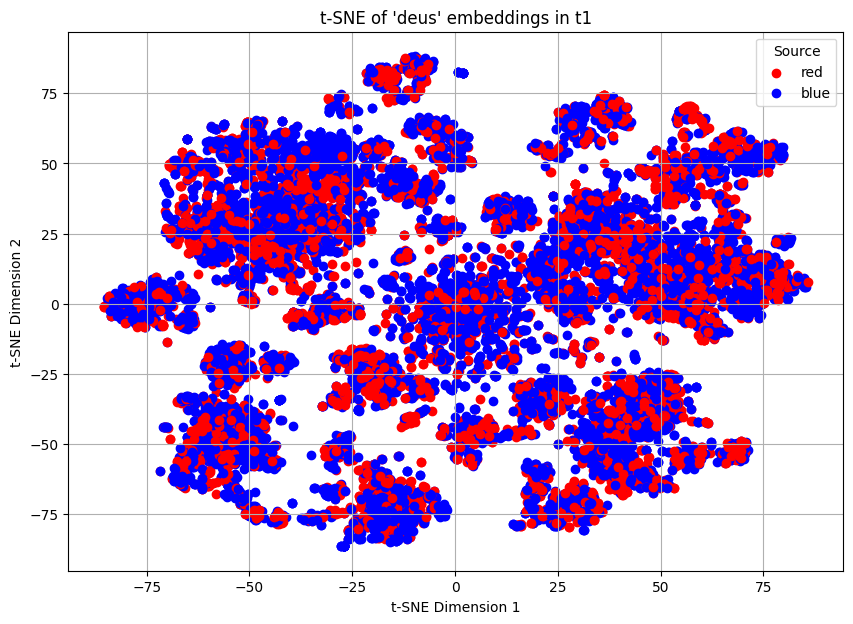

In [100]:
plot_token_embeddings_with_highlight_tsne(berts_finetuned_t1_lemmatized, time2corpus[1], corpus_christi, target_token='deus', n_components=2, perplexity=30)

#### t-SNE after PCA

In [103]:
word1 = 'oratio'
embeddings_t0_word1 = selected_word_embeddings_t0_finetuned[word1]
embeddings_t1_word1 = selected_word_embeddings_t1_finetuned[word1]

# Convert the list of embeddings to a numpy array
embeddings_array_t0_word1 = np.array(embeddings_t0_word1)
embeddings_array_t1_word1 = np.array(embeddings_t1_word1)

Plot saved to: /Users/valentinalunardi/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/TSNE/tsne-pca_embeddings_oratio_t0_finetuned.png


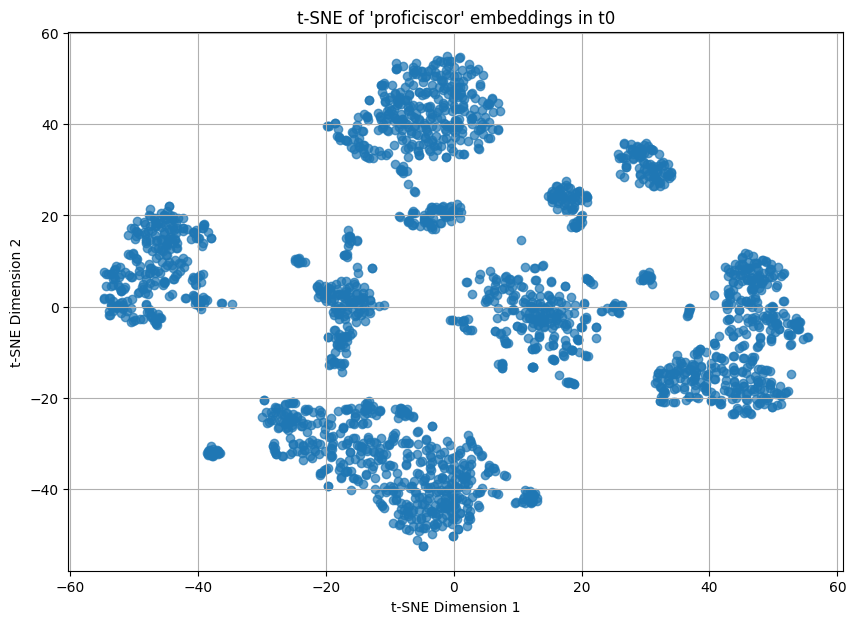

Trustworthiness: 0.988


In [110]:
X_pca, X_tsne = visualize_embeddings_pca_tsne(
    embeddings=embeddings_array_t0_word1,
    title=f"t-SNE of '{word}' embeddings in t0",
    save_path=os.path.join(dir_out, "TSNE"),
    word="oratio",
    timepoint="t0",
    finetuned=True
)
score = trustworthiness(X_pca, X_tsne, n_neighbors=5)
print(f"Trustworthiness: {score:.3f}")

Plot saved to: /Users/valentinalunardi/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/TSNE/tsne-pca_embeddings_oratio_t1_finetuned.png


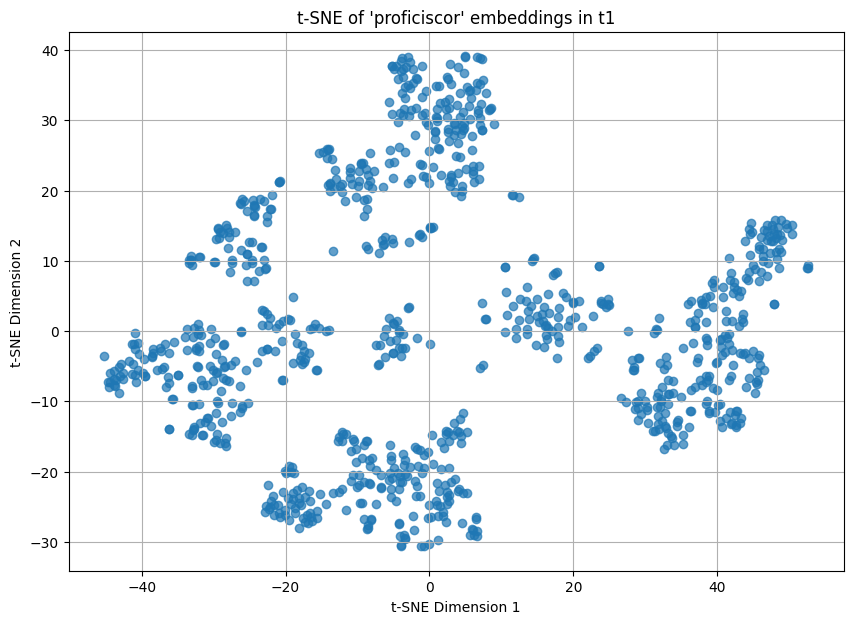

Trustworthiness: 0.981


In [111]:
X_pca, X_tsne = visualize_embeddings_pca_tsne(
    embeddings=embeddings_array_t1_word1,
    title=f"t-SNE of '{word}' embeddings in t1",
    save_path=os.path.join(dir_out, "TSNE"),
    word="oratio",
    timepoint="t1",
    finetuned=True
)
score = trustworthiness(X_pca, X_tsne, n_neighbors=5)
print(f"Trustworthiness: {score:.3f}")

#### Optimal clusters + silhouette score

In [71]:
# 1. Pick your word and get its embeddings
word = "lex"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'lex': 10, Silhouette Score: 0.0900


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


NameError: name 'average_embeddings_t1_finetuned' is not defined

In [102]:
# 1. Pick your word and get its embeddings
word = "lex"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'lex': 2, Silhouette Score: 0.0631


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'lex':
  lex: 0.9909
  paelex: 0.8357
  formula: 0.8212
  foedus: 0.8203
  ius: 0.8188
  praeceptum: 0.8182
  sententia: 0.8158
  iudicium: 0.8145
  sancio: 0.8135
  religio: 0.8097

Cluster 2 neighbors for 'lex':
  lex: 0.9908
  formula: 0.8755
  praeceptum: 0.8690
  regula: 0.8662
  ius: 0.8629
  iura: 0.8609
  foedus: 0.8531
  paelex: 0.8468
  religio: 0.8413
  libertas: 0.8398


In [103]:
# 1. Pick your word and get its embeddings
word = "oratio"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'oratio': 2, Silhouette Score: 0.1331


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'oratio':
  oratio: 0.9751
  dictio: 0.9013
  orator: 0.8879
  disputatio: 0.8857
  sermo: 0.8795
  locutio: 0.8751
  narratio: 0.8743
  eloquentia: 0.8728
  historia: 0.8590
  expositio: 0.8562

Cluster 2 neighbors for 'oratio':
  oratio: 0.9776
  oblatio: 0.8679
  hymnus: 0.8624
  precatio: 0.8577
  sacrificium: 0.8565
  lectio: 0.8535
  oro: 0.8531
  confessio: 0.8531
  supplicatio: 0.8529
  obsecratio: 0.8505


In [104]:
# 1. Pick your word and get its embeddings
word = "oratio"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'oratio': 3, Silhouette Score: 0.1059


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'oratio':
  oratio: 0.8951
  locutio: 0.8465
  sermo: 0.8134
  actio: 0.8021
  dictio: 0.8004
  accusatio: 0.7971
  eloquentia: 0.7935
  compositio: 0.7905
  orator: 0.7888
  loquor: 0.7878

Cluster 2 neighbors for 'oratio':
  oratio: 0.9897
  orator: 0.8933
  sermo: 0.8917
  eloquentia: 0.8873
  disputatio: 0.8725
  actio: 0.8716
  accusatio: 0.8706
  compositio: 0.8671
  narratio: 0.8616
  dictio: 0.8594

Cluster 3 neighbors for 'oratio':
  oratio: 0.9851
  sermo: 0.9022
  accusatio: 0.8859
  disputatio: 0.8769
  actio: 0.8705
  interrogatio: 0.8655
  eloquentia: 0.8626
  locutio: 0.8605
  legatio: 0.8596
  sententia: 0.8561


In [106]:
# 1. Pick your word and get its embeddings
word = "panis"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'panis': 2, Silhouette Score: 0.0969

Cluster 1 neighbors for 'panis':
  panis: 0.9860
  far: 0.8870
  frumentum: 0.8820
  potus: 0.8799
  lac: 0.8754
  coena: 0.8737
  salis: 0.8726
  sal: 0.8714
  cibus: 0.8709
  cena: 0.8696

Cluster 2 neighbors for 'panis':
  panis: 0.9813
  cibus: 0.8902
  mel: 0.8744
  far: 0.8661
  sal: 0.8587
  oleum: 0.8568
  frumentum: 0.8482
  lac: 0.8481
  caro: 0.8454
  caseus: 0.8422


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [105]:
# 1. Pick your word and get its embeddings
word = "panis"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'panis': 3, Silhouette Score: 0.0805


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'panis':
  panis: 0.9891
  cibus: 0.9063
  frumentum: 0.8807
  cibo: 0.8807
  lac: 0.8704
  mensa: 0.8667
  far: 0.8641
  sumptus: 0.8604
  cena: 0.8596
  cinis: 0.8563

Cluster 2 neighbors for 'panis':
  panis: 0.9911
  cibus: 0.9013
  frumentum: 0.8719
  lac: 0.8645
  mel: 0.8468
  adeps: 0.8436
  cena: 0.8426
  pisciculus: 0.8407
  far: 0.8380
  sal: 0.8366

Cluster 3 neighbors for 'panis':
  panis: 0.9012
  cibus: 0.8277
  lac: 0.7981
  cibo: 0.7971
  matthaeus: 0.7940
  frumentum: 0.7878
  psal: 0.7849
  mensa: 0.7814
  sumptus: 0.7807
  cena: 0.7772


In [108]:
# 1. Pick your word and get its embeddings
word = "gloria"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'gloria': 5, Silhouette Score: 0.0685


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'gloria':
  gloria: 0.9892
  laus: 0.9038
  honor: 0.8958
  potentia: 0.8697
  gratia: 0.8659
  decus: 0.8634
  praemium: 0.8612
  dignitas: 0.8574
  fama: 0.8528
  laetitia: 0.8523

Cluster 2 neighbors for 'gloria':
  gloria: 0.9878
  laus: 0.9128
  honor: 0.8997
  potentia: 0.8920
  praemium: 0.8908
  infamia: 0.8825
  gratia: 0.8799
  titulus: 0.8720
  laetitia: 0.8713
  dignitas: 0.8701

Cluster 3 neighbors for 'gloria':
  gloria: 0.9761
  honor: 0.8748
  dignitas: 0.8650
  laus: 0.8647
  potentia: 0.8604
  gratia: 0.8398
  claritudo: 0.8374
  praemium: 0.8366
  decus: 0.8332
  splendor: 0.8281

Cluster 4 neighbors for 'gloria':
  gloria: 0.9074
  laus: 0.8376
  honor: 0.8350
  potentia: 0.8273
  gratia: 0.8172
  praemium: 0.8135
  infamia: 0.8127
  gaudium: 0.8121
  decus: 0.8114
  dolor: 0.8091

Cluster 5 neighbors for 'gloria':
  gloria: 0.9751
  laus: 0.8900
  potentia: 0.8731
  honor: 0.8729
  gaudium: 0.8708
  praemium: 0.8699
  fama: 0.8699
  decus: 

In [107]:
# 1. Pick your word and get its embeddings
word = "gloria"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'gloria': 2, Silhouette Score: 0.0965


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'gloria':
  gloria: 0.9884
  laus: 0.9030
  praemium: 0.8945
  honor: 0.8909
  gratia: 0.8871
  potentia: 0.8865
  gaudium: 0.8858
  fama: 0.8670
  laetitia: 0.8666
  decus: 0.8665

Cluster 2 neighbors for 'gloria':
  gloria: 0.9825
  gratia: 0.8767
  potentia: 0.8709
  laus: 0.8662
  honor: 0.8627
  laetitia: 0.8535
  gaudium: 0.8509
  ignominia: 0.8489
  sanctificatio: 0.8482
  gloriatio: 0.8478


In [110]:
# 1. Pick your word and get its embeddings
word = "gratia"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'gratia': 4, Silhouette Score: 0.0847


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'gratia':
  gratia: 0.9709
  causa: 0.8490
  misericordia: 0.8406
  beneficium: 0.8401
  gratis: 0.8388
  gloria: 0.8371
  memoria: 0.8324
  occasio: 0.8307
  honor: 0.8276
  potentia: 0.8275

Cluster 2 neighbors for 'gratia':
  gratia: 0.8569
  amicitia: 0.7580
  concordia: 0.7390
  memoria: 0.7358
  societas: 0.7333
  pax: 0.7185
  misericordia: 0.7166
  gloria: 0.7137
  honor: 0.7122
  contentio: 0.7099

Cluster 3 neighbors for 'gratia':
  gratia: 0.9836
  gloria: 0.8972
  honor: 0.8810
  potentia: 0.8739
  misericordia: 0.8716
  beneficium: 0.8623
  amicitia: 0.8571
  memoria: 0.8527
  laus: 0.8465
  dignitas: 0.8460

Cluster 4 neighbors for 'gratia':
  gratia: 0.9876
  gloria: 0.8537
  honor: 0.8491
  beneficium: 0.8434
  misericordia: 0.8311
  memoria: 0.8283
  laus: 0.8262
  contumelia: 0.8206
  statua: 0.8202
  pecunia: 0.8186


In [109]:
# 1. Pick your word and get its embeddings
word = "gratia"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'gratia': 2, Silhouette Score: 0.1231


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'gratia':
  gratia: 0.9948
  gloria: 0.9011
  beneficium: 0.8815
  misericordia: 0.8795
  donum: 0.8724
  benedictio: 0.8693
  indulgentia: 0.8653
  potentia: 0.8614
  miseratio: 0.8570
  laus: 0.8557

Cluster 2 neighbors for 'gratia':
  gratia: 0.9511
  gratis: 0.8407
  beneficium: 0.8396
  causa: 0.8341
  occasio: 0.8267
  memoria: 0.8260
  amicitia: 0.8256
  indulgentia: 0.8239
  odium: 0.8199
  gloria: 0.8193


In [111]:
# 1. Pick your word and get its embeddings
word = "dominus"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'dominus': 2, Silhouette Score: 0.0670


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'dominus':
  dominus: 0.9880
  domina: 0.9287
  domino: 0.8707
  custos: 0.8547
  rector: 0.8485
  tyrannus: 0.8440
  hospes: 0.8412
  genitor: 0.8392
  famulus: 0.8356
  liber: 0.8349

Cluster 2 neighbors for 'dominus':
  dominus: 0.9930
  domina: 0.9034
  domino: 0.8852
  dominium: 0.8681
  tyrannus: 0.8669
  liber: 0.8597
  custos: 0.8543
  patronus: 0.8529
  libertas: 0.8506
  hospes: 0.8499


In [112]:
# 1. Pick your word and get its embeddings
word = "dominus"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'dominus': 2, Silhouette Score: 0.1159


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'dominus':
  dominus: 0.9912
  deus: 0.8337
  domina: 0.8308
  dominator: 0.7976
  iesus: 0.7963
  pharao: 0.7946
  christus: 0.7895
  dauid: 0.7876
  altissimus: 0.7868
  caesar: 0.7863

Cluster 2 neighbors for 'dominus':
  dominus: 0.9738
  domina: 0.9097
  deus: 0.8515
  christus: 0.8512
  caesar: 0.8467
  tyrannus: 0.8431
  domino: 0.8420
  libertas: 0.8356
  augustus: 0.8343
  princeps: 0.8327


In [113]:
# 1. Pick your word and get its embeddings
word = "deus"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'deus': 3, Silhouette Score: 0.0886


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'deus':
  deus: 0.9356
  dea: 0.9008
  iuppiter: 0.8712
  deo: 0.8238
  apollo: 0.8190
  numen: 0.8135
  senex: 0.8074
  dis: 0.8051
  diana: 0.8007
  sacerdos: 0.8002

Cluster 2 neighbors for 'deus':
  deus: 0.9968
  dea: 0.9254
  iuppiter: 0.9167
  numen: 0.8740
  apollo: 0.8587
  deo: 0.8556
  dis: 0.8543
  diuus: 0.8484
  semideus: 0.8429
  divinus: 0.8363

Cluster 3 neighbors for 'deus':
  deus: 0.9637
  iuppiter: 0.8677
  dea: 0.8563
  numen: 0.8177
  diuos: 0.8173
  dis: 0.8144
  diuus: 0.8126
  deo: 0.8024
  divinus: 0.7912
  apollo: 0.7883


In [114]:
# 1. Pick your word and get its embeddings
word = "deus"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'deus': 2, Silhouette Score: 0.1820


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'deus':
  deus: 0.9980
  dea: 0.8931
  iuppiter: 0.8870
  dominus: 0.8556
  numen: 0.8492
  divinus: 0.8407
  christus: 0.8402
  semideus: 0.8339
  chaldeus: 0.8274
  apollo: 0.8239

Cluster 2 neighbors for 'deus':
  deus: 0.9022
  diuus: 0.7572
  chaldeus: 0.7544
  iuppiter: 0.7492
  iesus: 0.7438
  dominus: 0.7418
  dea: 0.7311
  deitas: 0.7301
  dominator: 0.7290
  rex: 0.7275


In [116]:
# 1. Pick your word and get its embeddings
word = "frater"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'frater': 2, Silhouette Score: 0.0745


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'frater':
  frater: 0.9867
  soror: 0.9190
  filius: 0.8902
  nepos: 0.8878
  parens: 0.8710
  filia: 0.8687
  sodalis: 0.8625
  mater: 0.8614
  collega: 0.8609
  gener: 0.8585

Cluster 2 neighbors for 'frater':
  frater: 0.9945
  soror: 0.9357
  parens: 0.9127
  mater: 0.9015
  sodalis: 0.8982
  nepos: 0.8944
  genitor: 0.8929
  coniunx: 0.8916
  hospes: 0.8844
  pater: 0.8835


In [115]:
# 1. Pick your word and get its embeddings
word = "frater"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'frater': 2, Silhouette Score: 0.0853


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'frater':
  frater: 0.9895
  soror: 0.9240
  parens: 0.8948
  sodalis: 0.8929
  amicus: 0.8826
  socius: 0.8795
  hospes: 0.8760
  coniunx: 0.8746
  discipulus: 0.8721
  collega: 0.8711

Cluster 2 neighbors for 'frater':
  frater: 0.9845
  soror: 0.9142
  patruus: 0.8684
  nepos: 0.8573
  consobrinus: 0.8565
  filius: 0.8560
  cognatus: 0.8482
  parens: 0.8434
  consanguineus: 0.8389
  coheres: 0.8389


In [120]:
# 1. Pick your word and get its embeddings
word = "uirtus"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'uirtus': 2, Silhouette Score: 0.0889


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'uirtus':
  uirtus: 0.9836
  bonitas: 0.8750
  honestum: 0.8723
  iustitia: 0.8694
  sapientia: 0.8692
  fortitudo: 0.8676
  laus: 0.8653
  philosophia: 0.8543
  prudentia: 0.8538
  felicitas: 0.8510

Cluster 2 neighbors for 'uirtus':
  uirtus: 0.9883
  pietas: 0.8812
  bonitas: 0.8803
  prudentia: 0.8747
  probitas: 0.8726
  laus: 0.8723
  nobilitas: 0.8683
  dignitas: 0.8675
  fortitudo: 0.8644
  decus: 0.8631


In [119]:
# 1. Pick your word and get its embeddings
word = "uirtus"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'uirtus': 2, Silhouette Score: 0.0744


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'uirtus':
  uirtus: 0.9968
  pietas: 0.8920
  bonitas: 0.8798
  nobilitas: 0.8787
  prudentia: 0.8715
  iustitia: 0.8690
  laus: 0.8677
  sanctitas: 0.8656
  probitas: 0.8643
  robur: 0.8625

Cluster 2 neighbors for 'uirtus':
  uirtus: 0.9805
  fortitudo: 0.8846
  potentia: 0.8815
  bonitas: 0.8776
  uis: 0.8766
  robur: 0.8752
  iustitia: 0.8690
  fortis: 0.8670
  prudentia: 0.8575
  laus: 0.8556


In [122]:
# 1. Pick your word and get its embeddings
word = "creator"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'creator': 2, Silhouette Score: 0.2199

Cluster 1 neighbors for 'creator':
  creatrix: 0.8403
  conditor: 0.8223
  rector: 0.8215
  magister: 0.7931
  alumnus: 0.7806
  numen: 0.7741
  minister: 0.7732
  praeses: 0.7731
  genitor: 0.7716
  parens: 0.7711

Cluster 2 neighbors for 'creator':
  incolas: 0.7896
  orio: 0.7837
  domino: 0.7792
  contenta: 0.7787
  servo: 0.7770
  concessum: 0.7770
  sor: 0.7756
  excessus: 0.7754
  atia: 0.7689
  sensum: 0.7681


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [123]:
# 1. Pick your word and get its embeddings
word = "creator"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=15)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'creator': 3, Silhouette Score: 0.0947


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'creator':
  creator: 0.9809
  conditor: 0.8846
  redemptor: 0.8509
  creatio: 0.8307
  genitor: 0.8175
  creatura: 0.8156
  creatrix: 0.8086
  patronus: 0.8052
  rector: 0.8042
  fabricator: 0.8030
  saluator: 0.8004
  elementum: 0.7932
  factor: 0.7867
  natura: 0.7857
  deus: 0.7844

Cluster 2 neighbors for 'creator':
  creator: 0.9761
  conditor: 0.8903
  redemptor: 0.8575
  creatrix: 0.8477
  rector: 0.8313
  genitor: 0.8293
  magister: 0.8241
  tyrannus: 0.8157
  patronus: 0.8134
  numen: 0.8113
  fabricator: 0.8101
  parens: 0.8100
  alumnus: 0.8096
  creatio: 0.8066
  elementum: 0.8021

Cluster 3 neighbors for 'creator':
  creator: 0.9780
  conditor: 0.8981
  redemptor: 0.8938
  creatio: 0.8719
  elementum: 0.8694
  domino: 0.8487
  providentia: 0.8452
  artifex: 0.8380
  attributus: 0.8377
  patriarcha: 0.8356
  genitor: 0.8346
  donatus: 0.8331
  salutare: 0.8326
  mediator: 0.8323
  unio: 0.8295


In [124]:
# 1. Pick your word and get its embeddings
word = "peccator"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'peccator': 4, Silhouette Score: 0.2221

Cluster 1 neighbors for 'peccator':
  peccator: 0.9057
  invenio: 0.7926
  undus: 0.7868
  vico: 0.7843
  invitus: 0.7799
  servo: 0.7796
  instantia: 0.7786
  passum: 0.7755
  cus: 0.7719
  caes: 0.7712

Cluster 2 neighbors for 'peccator':
  peccator: 0.9605
  delictum: 0.9045
  peccatum: 0.8944
  reatus: 0.8857
  iniquitas: 0.8818
  opprobrium: 0.8700
  contradictio: 0.8631
  redemptor: 0.8616
  confessio: 0.8611
  iudaei: 0.8602

Cluster 3 neighbors for 'peccator':
  invenio: 0.7972
  [SEP]: 0.7765
  contradictio: 0.7494
  instantia: 0.7493
  peccator: 0.7468
  solet: 0.7462
  odo: 0.7308
  iio: 0.7296
  ee: 0.7293
  affirmatio: 0.7282


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 4 neighbors for 'peccator':
  peccator: 0.8460
  sere: 0.8194
  vico: 0.8114
  gno: 0.8039
  invenio: 0.7988
  elo: 0.7987
  ror: 0.7928
  ras: 0.7904
  dae: 0.7775
  iio: 0.7766


In [125]:
# 1. Pick your word and get its embeddings
word = "peccator"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'peccator': 3, Silhouette Score: 0.0723


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'peccator':
  peccator: 0.9867
  iniquitas: 0.8852
  impius: 0.8760
  peccatum: 0.8750
  delictum: 0.8529
  innocens: 0.8459
  peccatrix: 0.8382
  malitia: 0.8370
  damnatio: 0.8343
  iustus: 0.8282

Cluster 2 neighbors for 'peccator':
  peccator: 0.9907
  delictum: 0.9004
  peccatum: 0.8904
  reatus: 0.8872
  iniquitas: 0.8837
  impius: 0.8816
  innocens: 0.8775
  damnatio: 0.8646
  miseria: 0.8595
  poenitentia: 0.8574

Cluster 3 neighbors for 'peccator':
  peccator: 0.9389
  iniquitas: 0.8615
  reatus: 0.8578
  impius: 0.8559
  peccatum: 0.8537
  innocens: 0.8531
  matthaeus: 0.8474
  delictum: 0.8447
  damnatio: 0.8384
  malitia: 0.8375


In [88]:
# 1. Pick your word and get its embeddings
word = "communio"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=1, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'communio': 2, Silhouette Score: 0.2733

Cluster 1 neighbors for 'communio':
  consortio: 0.9396
  coniunctio: 0.9246
  societas: 0.9121
  coniunctum: 0.9093
  communis: 0.8848
  concordia: 0.8835
  notitia: 0.8764
  aequalitas: 0.8749
  confusio: 0.8706
  similitudo: 0.8692

Cluster 2 neighbors for 'communio':
  communio: 0.9610
  iio: 0.8883
  ras: 0.8734
  passum: 0.8688
  invenio: 0.8573
  vico: 0.8565
  eno: 0.8548
  orio: 0.8469
  decima: 0.8445
  ico: 0.8429


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [89]:
# 1. Pick your word and get its embeddings
word = "communio"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=1, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'communio': 2, Silhouette Score: 0.1606

Cluster 1 neighbors for 'communio':
  communio: 0.9755
  participatio: 0.8557
  communicatio: 0.8543
  consortio: 0.8522
  societas: 0.8502
  baptismum: 0.8481
  sacerdotium: 0.8340
  damnatio: 0.8307
  persecutio: 0.8300
  congregatio: 0.8300

Cluster 2 neighbors for 'communio':
  communio: 0.9655
  communicatio: 0.9377
  participatio: 0.9360
  consortio: 0.9246
  consortium: 0.9168
  societas: 0.9164
  coniunctio: 0.9151
  coniunctum: 0.9134
  unio: 0.9090
  collectio: 0.9039


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [65]:
# 1. Pick your word and get its embeddings
word = "communio"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'communio': 2, Silhouette Score: 0.2764


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'communio':
  communio: 0.9538
  iio: 0.8769
  ras: 0.8563
  decima: 0.8496
  passum: 0.8491
  invenio: 0.8387
  vico: 0.8366
  invito: 0.8351
  eno: 0.8294
  sensum: 0.8272

Cluster 2 neighbors for 'communio':
  consortio: 0.9401
  coniunctio: 0.9223
  societas: 0.9007
  coniunctum: 0.8983
  communis: 0.8798
  concordia: 0.8759
  communio: 0.8752
  aequalitas: 0.8720
  notitia: 0.8685
  proprietas: 0.8682


In [68]:
# 1. Pick your word and get its embeddings
word = "communio"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'communio': 2, Silhouette Score: 0.1640

Cluster 1 neighbors for 'communio':
  communio: 0.9782
  communicatio: 0.8734
  participatio: 0.8677
  societas: 0.8576
  consortio: 0.8523
  baptismum: 0.8447
  communico: 0.8394
  sacerdotium: 0.8350
  congregatio: 0.8336
  coniunctio: 0.8283

Cluster 2 neighbors for 'communio':
  communio: 0.9660
  communicatio: 0.9324
  participatio: 0.9274
  consortio: 0.9265
  coniunctio: 0.9139
  societas: 0.9097
  consortium: 0.9084
  coniunctum: 0.8979
  unio: 0.8945
  collectio: 0.8912


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [78]:
# 1. Pick your word and get its embeddings
word = "communico"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'communico': 2, Silhouette Score: 0.0754


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'communico':
  communico: 0.9884
  inculco: 0.9129
  permisco: 0.9105
  conloco: 0.9075
  applico: 0.9057
  obico: 0.9008
  dedisco: 0.8996
  iunco: 0.8966
  evoco: 0.8958
  perseco: 0.8957

Cluster 2 neighbors for 'communico':
  communico: 0.9982
  conloco: 0.9241
  permisco: 0.9116
  colloco: 0.9112
  applico: 0.9079
  inculco: 0.9019
  deposco: 0.8975
  dedisco: 0.8931
  dedico: 0.8904
  manduco: 0.8882


In [79]:
# 1. Pick your word and get its embeddings
word = "communico"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'communico': 2, Silhouette Score: 0.0793


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster 1 neighbors for 'communico':
  communico: 0.9950
  applico: 0.9097
  manduco: 0.9073
  dedico: 0.9069
  suffoco: 0.8959
  indulco: 0.8957
  conloco: 0.8927
  abdico: 0.8901
  colloco: 0.8898
  inculco: 0.8858

Cluster 2 neighbors for 'communico':
  communico: 0.9899
  applico: 0.9268
  dedico: 0.9185
  conloco: 0.9113
  colloco: 0.9103
  inculco: 0.9080
  replico: 0.9018
  iunco: 0.9007
  abdico: 0.9005
  didico: 0.8988


In [90]:
# 1. Pick your word and get its embeddings
word = "communico"
embeddings = selected_word_embeddings_t1_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t1_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'communico': 2, Silhouette Score: 0.0788

Cluster 1 neighbors for 'communico':
  communico: 0.9937
  dedico: 0.9081
  manduco: 0.9059
  applico: 0.9054
  suffoco: 0.8954
  conloco: 0.8926
  colloco: 0.8910
  abdico: 0.8851
  inculco: 0.8816
  iunco: 0.8783

Cluster 2 neighbors for 'communico':
  communico: 0.9919
  applico: 0.9264
  dedico: 0.9230
  conloco: 0.9191
  colloco: 0.9179
  inculco: 0.9069
  abdico: 0.9014
  iunco: 0.8991
  suffoco: 0.8985
  replico: 0.8982


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [91]:
# 1. Pick your word and get its embeddings
word = "communico"
embeddings = selected_word_embeddings_t0_finetuned[word]

# 2. Find optimal number of clusters
best_k, best_score = optimal_num_clusters(embeddings, min_k=2, max_k=10)
print(f"Optimal number of clusters for '{word}': {best_k}, Silhouette Score: {best_score:.4f}")

# 3. Cluster the embeddings for that word
kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans.fit(np.array(embeddings))
cluster_centroids = kmeans.cluster_centers_

# 4. Function to find neighbors for a centroid
def find_neighbors_for_embedding(embedding, average_embeddings, top_k=5):
    all_words = list(average_embeddings.keys())
    all_embeddings = np.array([average_embeddings[w] for w in all_words])
    similarities = cosine_similarity(embedding.reshape(1, -1), all_embeddings).squeeze()
    neighbors = sorted(
        [(w, sim) for w, sim in zip(all_words, similarities)],
        key=lambda x: -x[1]
    )[:top_k]
    return neighbors

# 5. For each cluster centroid, find closest average lemma embeddings
for i, centroid in enumerate(cluster_centroids):
    neighbors = find_neighbors_for_embedding(centroid, average_embeddings_t0_finetuned, top_k=10)
    print(f"\nCluster {i+1} neighbors for '{word}':")
    for neighbor, sim in neighbors:
        print(f"  {neighbor}: {sim:.4f}")

Optimal number of clusters for 'communico': 2, Silhouette Score: 0.0924

Cluster 1 neighbors for 'communico':
  communico: 0.9964
  conloco: 0.9207
  colloco: 0.9090
  inculco: 0.9070
  applico: 0.9020
  evoco: 0.8943
  deposco: 0.8929
  fabrico: 0.8925
  dedisco: 0.8918
  dedico: 0.8914

Cluster 2 neighbors for 'communico':
  communico: 0.9935
  conloco: 0.9346
  colloco: 0.9269
  applico: 0.9187
  inculco: 0.9037
  deposco: 0.9034
  dedico: 0.9007
  dimico: 0.8989
  manduco: 0.8984
  dedisco: 0.8948


/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


#### Centroids with different clustering methods

In [ ]:
def extract_sense_prototypes(word_embeddings, clustering_cls=KMeans, num_clusters=3, **clustering_kwargs):
    """
    For each word, cluster its embeddings and return the cluster centroids as sense prototypes.
    clustering_cls: clustering class (e.g., KMeans, AffinityPropagation, etc.)
    num_clusters: number of clusters (if applicable)
    clustering_kwargs: additional arguments for the clustering class
    """
    sense_prototypes = {}
    for word, embeddings in word_embeddings.items():
        if len(embeddings) < num_clusters:
            sense_prototypes[word] = embeddings
        else:
            embeddings_array = np.array(embeddings)
            if clustering_cls == KMeans:
                clusterer = clustering_cls(n_clusters=num_clusters, random_state=0, **clustering_kwargs)
            else:
                clusterer = clustering_cls(**clustering_kwargs)
            clusterer.fit(embeddings_array)
            if hasattr(clusterer, "cluster_centers_"):
                sense_prototypes[word] = clusterer.cluster_centers_
            else:
                # For clustering algorithms without centroids, use exemplars or medoids if available
                sense_prototypes[word] = embeddings_array[clusterer.cluster_centers_indices_]
    return sense_prototypes

In [12]:
extract_sense_prototypes(selected_word_embeddings_t0_finetuned, clustering_cls=AffinityPropagation, num_clusters=2)

NameError: name 'extract_sense_prototypes' is not defined